In [370]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import casadi as ca
import cyecca.lie as lie
from cyecca.lie.group_so3 import SO3Quat, SO3EulerB321, so3, SO3Dcm
from cyecca.lie.group_se23 import SE23Quat, se23
from scipy.spatial.transform import Rotation
from scipy.stats import chi2

# MCAP/ROS bag reading imports. Prefer ROS 2 when available, otherwise use
# rosbags, which can read MCAP files without rclpy.
try:
    import rclpy
    from rclpy.serialization import deserialize_message
    from rosbag2_py import SequentialReader, StorageOptions, ConverterOptions
    from nav_msgs.msg import Odometry
    from sensor_msgs.msg import Imu, MagneticField
    MCAP_BACKEND = "rosbag2_py"
    MCAP_AVAILABLE = True
    print("MCAP reading libraries available via rosbag2_py")
except ImportError as ros_error:
    try:
        from rosbags.highlevel import AnyReader
        MCAP_BACKEND = "rosbags"
        MCAP_AVAILABLE = True
        print("MCAP reading libraries available via rosbags")
    except ImportError as rosbags_error:
        MCAP_BACKEND = None
        MCAP_AVAILABLE = False
        print(f"MCAP reading libraries not available: {ros_error}")
        print(f"rosbags fallback also not available: {rosbags_error}")
        print("Run this in the notebook kernel: %pip install rosbags")

# Set up plotting
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')  # fallback for older versions
    except:
        pass  # use default style if seaborn not available
plt.rcParams['figure.figsize'] = (12, 8)


MCAP reading libraries available via rosbags


In [371]:
# Constants
g = 9.8  # gravity acceleration m/s^2

def angle_wrap(angle):
    """Wrap angle to [-pi, pi]"""
    wrapped = ca.fmod(angle, 2 * ca.pi)
    wrapped = ca.if_else(wrapped < 0, wrapped + 2 * ca.pi, wrapped)
    return ca.if_else(wrapped > ca.pi, wrapped - 2 * ca.pi, wrapped)

def quat_to_euler(q):
    """Convert quaternion [w,x,y,z] to Euler angles [roll,pitch,yaw]"""
    r = Rotation.from_quat([q[1], q[2], q[3], q[0]])  # scipy uses [x,y,z,w]
    return r.as_euler('xyz', degrees=True)  # roll, pitch, yaw in degrees


In [372]:
def _stamp_to_seconds(stamp):
    return float(stamp.sec) + float(stamp.nanosec) * 1e-9


def _append_odom_sample(odom_data, msg):
    pos = msg.pose.pose.position
    ori = msg.pose.pose.orientation
    timestamp = _stamp_to_seconds(msg.header.stamp)
    euler_deg = Rotation.from_quat([ori.x, ori.y, ori.z, ori.w]).as_euler('xyz', degrees=True)
    odom_data.append({
        'timestamp': timestamp,
        'x': pos.x,
        'y': pos.y,
        'z': pos.z,
        'qw': ori.w,
        'qx': ori.x,
        'qy': ori.y,
        'qz': ori.z,
        'roll': euler_deg[0],
        'pitch': euler_deg[1],
        'yaw': euler_deg[2],
    })


def _append_imu_sample(imu_data, msg):
    imu_data.append({
        'timestamp': _stamp_to_seconds(msg.header.stamp),
        'gyro_x': msg.angular_velocity.x,
        'gyro_y': msg.angular_velocity.y,
        'gyro_z': msg.angular_velocity.z,
        'accel_x': msg.linear_acceleration.x,
        'accel_y': msg.linear_acceleration.y,
        'accel_z': msg.linear_acceleration.z,
    })


def _append_mag_sample(mag_data, msg):
    mag_data.append({
        'timestamp': _stamp_to_seconds(msg.header.stamp),
        'mag_x': msg.magnetic_field.x,
        'mag_y': msg.magnetic_field.y,
        'mag_z': msg.magnetic_field.z,
    })


def _print_loaded_summary(imu_df, mag_df, odom_df):
    print("\nData loaded:")
    if imu_df is not None:
        print(f"IMU: {len(imu_df)} samples, time range: {imu_df['timestamp'].min():.2f} - {imu_df['timestamp'].max():.2f} s")
    if mag_df is not None:
        print(f"Magnetometer: {len(mag_df)} samples, time range: {mag_df['timestamp'].min():.2f} - {mag_df['timestamp'].max():.2f} s")
    if odom_df is not None:
        print(f"True attitude: {len(odom_df)} samples, time range: {odom_df['timestamp'].min():.2f} - {odom_df['timestamp'].max():.2f} s")


def _as_dataframes(imu_data, mag_data, odom_data):
    imu_df = pd.DataFrame(imu_data) if imu_data else None
    mag_df = pd.DataFrame(mag_data) if mag_data else None
    odom_df = pd.DataFrame(odom_data) if odom_data else None
    _print_loaded_summary(imu_df, mag_df, odom_df)
    return imu_df, mag_df, odom_df


def _read_mcap_data_rosbags(mcap_file_path, odom_topic, imu_topic, mag_topic):
    bag_path = Path(mcap_file_path)
    if not bag_path.exists():
        raise FileNotFoundError(f"MCAP path does not exist: {bag_path}")

    imu_data = []
    mag_data = []
    odom_data = []

    print(f"Reading data from {bag_path} with rosbags")
    print(f"Looking for topics: {odom_topic}, {imu_topic}, {mag_topic}")

    with AnyReader([bag_path]) as reader:
        wanted_topics = {odom_topic, imu_topic, mag_topic}
        connections = [conn for conn in reader.connections if conn.topic in wanted_topics]
        if not connections:
            available = sorted({conn.topic for conn in reader.connections})
            raise ValueError(f"None of the requested topics were found. Available topics: {available}")

        msg_count = 0
        for connection, _, rawdata in reader.messages(connections=connections):
            msg_count += 1
            if msg_count % 1000 == 0:
                print(f"Processed {msg_count} messages...")

            msg = reader.deserialize(rawdata, connection.msgtype)
            if connection.topic == odom_topic:
                _append_odom_sample(odom_data, msg)
            elif connection.topic == imu_topic:
                _append_imu_sample(imu_data, msg)
            elif connection.topic == mag_topic:
                _append_mag_sample(mag_data, msg)

    return _as_dataframes(imu_data, mag_data, odom_data)


def _read_mcap_data_rosbag2_py(mcap_file_path, odom_topic, imu_topic, mag_topic):
    storage_options = StorageOptions(uri=mcap_file_path, storage_id='mcap')
    converter_options = ConverterOptions(input_serialization_format='cdr', output_serialization_format='cdr')

    reader = SequentialReader()
    reader.open(storage_options, converter_options)

    imu_data = []
    mag_data = []
    odom_data = []

    print(f"Reading data from {mcap_file_path} with rosbag2_py")
    print(f"Looking for topics: {odom_topic}, {imu_topic}, {mag_topic}")

    msg_count = 0
    while reader.has_next():
        current_topic, msg_data, _ = reader.read_next()
        msg_count += 1
        if msg_count % 1000 == 0:
            print(f"Processed {msg_count} messages...")

        if current_topic == odom_topic:
            _append_odom_sample(odom_data, deserialize_message(msg_data, Odometry))
        elif current_topic == imu_topic:
            _append_imu_sample(imu_data, deserialize_message(msg_data, Imu))
        elif current_topic == mag_topic:
            _append_mag_sample(mag_data, deserialize_message(msg_data, MagneticField))

    reader.close()
    return _as_dataframes(imu_data, mag_data, odom_data)


def read_mcap_data(mcap_file_path, odom_topic="/odom", imu_topic="/imu", mag_topic="/mag"):
    """Read IMU, magnetometer, and true attitude data from an MCAP file."""
    if not MCAP_AVAILABLE:
        print("MCAP libraries not available. Run: %pip install rosbags")
        return None, None, None

    try:
        if MCAP_BACKEND == "rosbags":
            return _read_mcap_data_rosbags(mcap_file_path, odom_topic, imu_topic, mag_topic)
        return _read_mcap_data_rosbag2_py(mcap_file_path, odom_topic, imu_topic, mag_topic)
    except Exception as e:
        print(f"Error reading MCAP file: {e}")
        return None, None, None


In [373]:
def derive_strapdown_ins_propagation():
    """INS strapdown propagation using SE(2,3) group"""
    dt = ca.SX.sym("dt")
    X0 = lie.SE23Quat.elem(ca.SX.sym("X0", 10))
    a_b = ca.SX.sym("a_b", 3)
    g_val = ca.SX.sym("g")
    omega_b = ca.SX.sym("omega_b", 3)
    l = lie.se23.elem(ca.vertcat(0, 0, 0, a_b, omega_b))
    r = lie.se23.elem(ca.vertcat(0, 0, 0, 0, 0, -g_val, 0, 0, 0))
    B = ca.sparsify(ca.SX([[0, 1], [0, 0]]))
    X1 = lie.SE23Quat.exp_mixed(X0, l * dt, r * dt, B * dt)
    
    f_ins = ca.Function(
        "strapdown_ins_propagate",
        [X0.param, a_b, omega_b, g_val, dt],
        [X1.param],
        ["x0", "a_b", "omega_b", "g", "dt"],
        ["x1"]
    )
    
    return f_ins

def extract_quaternion_from_se23(X):
    """Extract quaternion from SE(2,3) state vector"""
    # SE(2,3) state: [pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, qw, qx, qy, qz]
    return X[6:10]  # quaternion is at indices 6-9

def extract_position_from_se23(X):
    """Extract position from SE(2,3) state vector"""
    # SE(2,3) state: [pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, qw, qx, qy, qz]
    return X[0:3]  # position is at indices 0-2

def extract_position_from_odom(odom_df, timestamp):
    """Extract position from odom DataFrame for a given timestamp.
    
    Args:
        odom_df: DataFrame containing odometry data with columns ['timestamp', 'x', 'y', 'z']
        timestamp: Timestamp to extract position for
        
    Returns:
        numpy array of [x, y, z] position
    """
    if 'timestamp' not in odom_df.columns or 'x' not in odom_df.columns:
        raise ValueError("odom_df must contain 'timestamp', 'x', 'y', 'z' columns")
    
    idx = np.searchsorted(odom_df['timestamp'], timestamp)
    if idx >= len(odom_df):
        idx = len(odom_df) - 1
    elif idx > 0 and abs(odom_df.iloc[idx]['timestamp'] - timestamp) > abs(odom_df.iloc[idx-1]['timestamp'] - timestamp):
        idx = idx - 1
    
    return np.array([
        odom_df.iloc[idx]['x'],
        odom_df.iloc[idx]['y'],
        odom_df.iloc[idx]['z']
    ])

def extract_position_from_odom_interp(true_position_interp, timestep_idx):
    """Extract position from interpolated position DataFrame for a given timestep index.
    
    Args:
        true_position_interp: DataFrame containing interpolated position data
        timestep_idx: Index of the timestep (matches IMU timestep index)
        
    Returns:
        numpy array of [x, y, z] position
    """
    return np.array([
        true_position_interp.iloc[timestep_idx]['x'],
        true_position_interp.iloc[timestep_idx]['y'],
        true_position_interp.iloc[timestep_idx]['z']
    ])

def create_se23_state(pos, vel, quat):
    """Create SE(2,3) state vector from position, velocity, and quaternion"""
    return np.concatenate([pos, vel, quat])

# Create the functions
ins_propagate = derive_strapdown_ins_propagation()

In [374]:
def derive_position_correction():
    ## Initilaizing measurments
    gps = ca.SX.sym("gps", 3)
    accel = ca.SX.sym("accel", 3)
    accel_state = ca.SX.sym("accel_state", 3)
    dt = ca.SX.sym("dt", 1)
    P = ca.SX.sym("P", 9, 9)

    # Initialize state
    est_x = ca.SX.sym("est", 10)  # [x,y,z,u,v,w,q0,q1,q2,q3]
    x0 = ca.vertcat(est_x[0:6], accel_state)  # [x,y,z,u,v,w,ax,ay,az]

    # Define the state transition matrix (A)
    A = ca.SX.eye(9)
    A[0:3, 3:6] = np.eye(3) * dt  # position integrates velocity
    A[3:6, 6:9] = np.eye(3) * dt  # velocity integrates acceleration

    ## TODO: may need to pass Q and R throught the casadi function
    Q = np.eye(9) * 1e-5  # Process noise (uncertainty in system model)
    H = ca.horzcat(ca.SX.eye(3), ca.SX.zeros(3, 3), ca.SX.zeros(3, 3))
    R = np.eye(3) * 1e-2  # GPS position noise (tune as needed)

    # extrapolate uncertainty
    P_s = A @ P @ A.T + Q

    ## Measurment Update
    S = H @ P_s @ H.T + ca.SX(R)

    # Update Kalman Gain
    K = P_s @ H.T @ ca.inv(S)

    # Update estimate w/ measurment
    z = gps
    x_upd = x0 + K @ (z - H @ x0)

    # Update the measurement uncertainty
    P_new = (ca.SX.eye(9) - (K @ H)) @ P_s

    # Extract accel state and construct output state
    accel_state_new = x_upd[6:9]
    x_new = ca.vertcat(x_upd[0:6], ca.SX.zeros(4))

    f_pos_correction = ca.Function(
        "position_correction",
        [
            est_x,
            gps,
            accel,
            accel_state,
            dt,
            P,
        ],
        [x_new, P_new, accel_state_new],
        [
            "est_x",
            "gps",
            "accel",
            "accel_state",
            "dt",
            "P",
        ],
        ["x_new", "P_new", "accel_state_new"],
    )
    return f_pos_correction

position_correction = derive_position_correction()

In [375]:
def derive_attitude_estimator_basic():
    # Define Casadi variables
    q = ca.SX.sym("q", 4)
    mag_b = ca.SX.sym("mag", 3)
    mag_decl = ca.SX.sym("mag_decl", 1)
    omega_b = ca.SX.sym("omega_b", 3)
    accel_b = ca.SX.sym("accel", 3)
    accel_gps = ca.SX.sym("accel_gps", 3)
    accel_gain = ca.SX.sym("accel_gain", 1)
    mag_gain = ca.SX.sym("mag_gain", 1)
    dt = ca.SX.sym("dt", 1)
    P_att = ca.SX.sym("P_att", 3, 3)

    # Convert quaternion to SO3Quat object
    q_wb = SO3Quat.elem(param=q)

    # Correction angular velocity vector
    correction_w = ca.SX.zeros(3, 1)

    # ----- Magnetometer correction (yaw) -----
    # Transform magnetometer to world frame
    mag_earth = q_wb @ mag_b

    # Magnetometer error calculation
    mag_error_w = -angle_wrap(ca.atan2(mag_earth[1], mag_earth[0]) + mag_decl - ca.pi / 2)

    # Check if magnetic heading is not too vertical
    gamma = ca.acos(mag_b[2] / ca.norm_2(mag_b))
    mag_error_w = ca.if_else(ca.sin(gamma) > 0.1, mag_error_w, 0)

    # Apply magnetometer correction
    correction_w += ca.vertcat(0, 0, mag_error_w) * mag_gain

    # ----- Accelerometer correction (roll/pitch) -----
    # Transform acceleration to world frame
    accel_w = q_wb @ accel_b
    accel_norm = ca.norm_2(accel_w)
    accel_w_normed = accel_w / accel_norm

    # Only correct if acceleration is close to gravity
    threshold = 0.1 # 10%
    higher_lim_check = ca.if_else(accel_norm < g * (1 + threshold), 1, 0)
    lower_lim_check = ca.if_else(accel_norm > g * (1 - threshold), 1, 0)
    accel_norm_check = higher_lim_check * lower_lim_check

    # Reduce gain when accelerating
    accel_gain_magnitude = 1 - ca.fabs(((accel_norm - g) / (1.01 * threshold * g)))
    accel_gain_magnitude = ca.if_else(accel_gain_magnitude < 0, 1e-3, accel_gain_magnitude)

    accel_cross = ca.cross(ca.vertcat(0, 0, 1), accel_w_normed)
    accel_error_w = ca.asin(ca.norm_2(accel_cross)) * accel_cross / ca.norm_2(accel_cross)

    # Calculate correction
    accel_correction = -(
        ca.vertcat(accel_error_w[0], accel_error_w[1], 0)
        * accel_gain
        * accel_norm_check
        * accel_gain_magnitude
    )
    correction_w += accel_correction

    # Limit correction magnitude
    correction_limit = 0.1 # add to config maybe???
    correction_magnitude = ca.norm_2(correction_w)
    correction_w = ca.if_else(
        correction_magnitude > correction_limit,
        correction_w * correction_limit / correction_magnitude,
        correction_w
    )

    # Apply correction
    q_new = so3.elem(correction_w * dt).exp(SO3Quat) * q_wb

    # Normalize quaternion
    q_new = SO3Quat.elem(q_new.param / ca.norm_2(q_new.param))

    P_att_new = P_att

    # Return estimator
    f_att_estimator = ca.Function(
        "attitude_estimator",
        [
            q,
            mag_b,
            mag_decl,
            omega_b,
            accel_b,
            accel_gps,
            accel_gain,
            mag_gain,
            dt,
            P_att,
        ],
        [q_new.param, P_att_new],
        [
            "q",
            "mag_b",
            "mag_decl",
            "omega_b",
            "accel_b",
            "accel_gps",
            "accel_gain",
            "mag_gain",
            "dt",
            "P_att",
        ],
        ["q_new", "P_att_new"],
    )

    return f_att_estimator


attitude_estimator_basic = derive_attitude_estimator_basic()

In [376]:
def derive_attitude_estimator_basic_updated():
    # Define Casadi variables
    q = ca.SX.sym("q", 4)
    mag_b = ca.SX.sym("mag", 3)
    mag_decl = ca.SX.sym("mag_decl", 1)
    omega_b = ca.SX.sym("omega_b", 3)
    accel_b = ca.SX.sym("accel", 3)
    accel_state = ca.SX.sym("accel_gps", 3)
    accel_gain = ca.SX.sym("accel_gain", 1)
    mag_gain = ca.SX.sym("mag_gain", 1)
    dt = ca.SX.sym("dt", 1)
    P_att = ca.SX.sym("P_att", 3, 3)

    # Convert quaternion to SO3Quat object
    q_wb = SO3Quat.elem(param=q)

    # Correction angular velocity vector
    correction_w = ca.SX.zeros(3, 1)

    # ----- Magnetometer correction (yaw) -----
    # Transform magnetometer to world frame
    mag_earth = q_wb @ mag_b

    # Magnetometer error calculation
    mag_error_w = -angle_wrap(ca.atan2(mag_earth[1], mag_earth[0]) + mag_decl - ca.pi / 2)

    # Check if magnetic heading is not too vertical
    gamma = ca.acos(mag_b[2] / ca.norm_2(mag_b))
    mag_error_w = ca.if_else(ca.sin(gamma) > 0.1, mag_error_w, 0)

    # Apply magnetometer correction
    correction_w += ca.vertcat(0, 0, mag_error_w) * mag_gain

    # ----- Accelerometer correction (roll/pitch) -----
    # Transform acceleration to world frame
    accel_w = q_wb @ accel_b
    accel_delta = ca.vertcat(accel_w[0] - accel_state[0], accel_w[1] + accel_state[1], accel_b[2])
    accel_norm = ca.norm_2(accel_w)
    accel_w_normed = accel_w / ca.norm_2(accel_delta)

    # Only correct if acceleration is close to gravity
    threshold = 0.1 # 10%
    higher_lim_check = ca.if_else(accel_norm < g * (1 + threshold), 1, 0)
    lower_lim_check = ca.if_else(accel_norm > g * (1 - threshold), 1, 0)
    accel_norm_check = higher_lim_check * lower_lim_check

    # Reduce gain when accelerating
    accel_gain_magnitude = 1 - ca.fabs(((accel_norm - g) / (1.01 * threshold * g)))
    

    accel_cross = ca.cross(ca.vertcat(0, 0, 1), accel_w_normed)
    accel_error_w = ca.asin(ca.norm_2(accel_cross)) * accel_cross / ca.norm_2(accel_cross)

    # Calculate correction
    accel_correction = -(
        ca.vertcat(accel_error_w[0], accel_error_w[1], 0)
        * accel_gain
        * accel_norm_check
        * accel_gain_magnitude
    )
    correction_w += accel_correction

    # Limit correction magnitude
    # correction_limit = 0.1 # add to config maybe???
    # correction_magnitude = ca.norm_2(correction_w)
    # correction_w = ca.if_else(
    #     correction_magnitude > correction_limit,
    #     correction_w * correction_limit / correction_magnitude,
    #     correction_w
    # )

    # Apply correction
    q_new = so3.elem(correction_w * dt).exp(SO3Quat) * q_wb

    # Normalize quaternion
    q_new = SO3Quat.elem(q_new.param / ca.norm_2(q_new.param))

    P_att_new = P_att
    accel_gps1 = accel_state

    # Return estimator
    f_att_estimator = ca.Function(
        "attitude_estimator",
        [
            q,
            mag_b,
            mag_decl,
            omega_b,
            accel_b,
            accel_state,
            accel_gain,
            mag_gain,
            dt,
            P_att,
        ],
        [q_new.param, P_att_new, accel_w, accel_gps1],
        [
            "q",
            "mag_b",
            "mag_decl",
            "omega_b",
            "accel_b",
            "accel_gps",
            "accel_gain",
            "mag_gain",
            "dt",
            "P_att",
        ],
        ["q_new", "P_att_new", "accel_w", "accel_gps1"],
    )

    return f_att_estimator


attitude_estimator_basic_updated = derive_attitude_estimator_basic_updated()

In [377]:
def derive_attitude_estimator_IEKF():
    # Define Casadi variables
    q0 = ca.SX.sym("q", 4)
    q_wb = SO3Quat.elem(param=q0)
    mag_b = ca.SX.sym("mag", 3)
    mag_decl = ca.SX.sym("mag_decl", 1)
    omega_b = ca.SX.sym("omega_b", 3)
    accel_b = ca.SX.sym("accel", 3)
    accel_gain = ca.SX.sym("accel_gain", 1)
    mag_gain = ca.SX.sym("mag_gain", 1)
    dt = ca.SX.sym("dt", 1)
    P = ca.SX.sym("P", 3, 3)

    # Note:
    # Magnetometer frame: x is east, y is north, z is up
    # Body frame: x is forward, y is left, z is down
    # World frame: x is east, y is north, z is up

    # Correction angular velocity vector
    error_w = ca.SX.zeros(3, 1)

    # # --- Correction from magnetometer (yaw) ---

    # Transform magnetometer to world frame
    mag_earth = q_wb @ mag_b

    # Magnetometer error calculation
    mag_error_w = -angle_wrap(ca.atan2(mag_earth[1], mag_earth[0]) + mag_decl - ca.pi / 2) # the magnetic north is at (90 degrees - mag_decl) yaw

    # mag check
    gamma = ca.acos(mag_b[2] / ca.norm_2(mag_b))  # angle from vertical
    mag_error_check = ca.if_else(ca.sin(gamma) > 0.1, 0, 1)

    error_w += (ca.vertcat(0,0,mag_error_w))

    # # --- Correction from accelerometer (roll/pitch) ---

    # Transform acceleration in world frame
    accel_w = q_wb @ accel_b 
    accel_norm = ca.norm_2(accel_w)
    accel_w_normed = accel_w / accel_norm

    # Correct accelerometer only if g between 0.9g and 1.1g
    threshold = 0.05
    higher_lim_check = ca.if_else(ca.fabs(accel_w_normed[2]) < (1 + threshold), 0, 1) * ca.if_else(accel_norm < g * (1 + threshold), 0, 1)
    lower_lim_check = ca.if_else(ca.fabs(accel_w_normed[2]) > (1 - threshold), 0, 1) * ca.if_else(accel_norm > g * (1 - threshold), 0, 1)
    accel_norm_check = higher_lim_check * lower_lim_check

    # Acceleration gain
    # If the drone is accelerating, we shouldn't trust the accelerometer
    accel_gain_magnitude = 1 - ca.fabs(((accel_norm - g) / (1.01 * threshold * g)))
    accel_gain_magnitude = ca.if_else(accel_gain_magnitude < 0, 1e-3, accel_gain_magnitude)
    
    # Correct gravity as z
    error_w -= (
        ca.cross(ca.vertcat(0,0,1), ca.vertcat(accel_w_normed[0],accel_w_normed[1],accel_w_normed[2]))
    )

    ## TODO add gyro bias stuff

    pitch_cov = 1e-1
    roll_cov = 1e-1
    yaw_cov = 1e-1
    
    L = ca.SX.zeros(3, 3)
    L[0,0] = pitch_cov / (accel_gain_magnitude * accel_gain) + 1e4 * accel_norm_check
    L[1,1] = roll_cov / (accel_gain_magnitude * accel_gain) + 1e4 * accel_norm_check
    L[2,2] = yaw_cov / (mag_gain) + 1e4 * mag_error_check
    Q = ca.SX.eye(3) * 1e-6

    # --- IEKF ---
    R = SO3Dcm.from_Quat(q_wb).to_Matrix()
    # Predict covariance
    F = so3.wedge(omega_b * dt).exp(SO3Dcm).to_Matrix()
    P_new = F @ P @ F.T + Q

    # Kalman Gain calculation
    H = ca.SX.eye(3)
    S = H @ P_new @ H.T + L
    K = P_new @ H.T @ ca.inv(S)

    # Correction
    correction_w = K @ error_w

    # Add saturation to prevent large jumps
    # max_correction = 0.1  # radians, tune this value
    # correction_norm = ca.norm_2(correction_w)
    # correction_w = ca.if_else(
    #     correction_norm > max_correction,
    #     correction_w * max_correction / correction_norm,
    #     correction_w
    # )

    q1 = so3.wedge(correction_w * dt).exp(SO3Quat) * q_wb

    # Return estimator
    f_att_estimator = ca.Function(
        "attitude_estimator",
        [
            q0,
            mag_b,
            mag_decl,
            omega_b,
            accel_b,
            accel_gain,
            mag_gain,
            dt,
            P,
        ],
        [q1.param, P_new],
        [
            "q",
            "mag_b",
            "mag_decl",
            "omega_b",
            "accel_b",
            "accel_gain",
            "mag_gain",
            "dt",
            "P",
        ],
        ["q1", "P_new"],
    )

    return f_att_estimator

attitude_estimator_IEKF = derive_attitude_estimator_IEKF()

In [378]:
# Parameters
MCAP_FILE_PATH = "sample/sample.mcap"
ODOM_TOPIC = "/odom"      # True attitude
IMU_TOPIC = "/imu"        # IMU data
MAG_TOPIC = "/mag"        # Magnetometer data

# Estimator parameters
ACCEL_GAIN = 0.55   # Accelerometer correction gain
MAG_GAIN = 0.55       # Magnetometer correction gain
MAG_DECLINATION = -4.494167/180 * np.pi     # Magnetic declination (rad)

# Data processing parameters
START_TIME = 0     # Start time (seconds)
END_TIME = 4000          # End time (seconds) 
MAX_TIMESTEPS = 10000  # Maximum number of timesteps to process

USE_IEKF = False

print(f"Configuration:")
print(f"  MCAP file: {MCAP_FILE_PATH}")
print(f"  Topics: {ODOM_TOPIC}, {IMU_TOPIC}, {MAG_TOPIC}")
print(f"  Time range: {START_TIME}s to {END_TIME}s")
print(f"  Max timesteps: {MAX_TIMESTEPS}")
print(f"  Gains: accel={ACCEL_GAIN}, mag={MAG_GAIN}")


Configuration:
  MCAP file: sample/sample.mcap
  Topics: /odom, /imu, /mag
  Time range: 0s to 4000s
  Max timesteps: 10000
  Gains: accel=0.55, mag=0.55


In [379]:
estimator_type = attitude_estimator_basic
#estimator_type = attitude_estimator_basic_updated
#estimator_type = attitude_estimator_IEKF

In [380]:
# Read data from MCAP file
print("Reading data from MCAP file...")
imu_data, mag_data, odom_data = read_mcap_data(MCAP_FILE_PATH, ODOM_TOPIC, IMU_TOPIC, MAG_TOPIC)

if imu_data is None or mag_data is None or odom_data is None:
    print("Error: Failed to load data from MCAP file")
else:
    print("\nData loaded successfully!")


Reading data from MCAP file...
Reading data from sample\sample.mcap with rosbags
Looking for topics: /odom, /imu, /mag
Processed 1000 messages...
Processed 2000 messages...
Processed 3000 messages...
Processed 4000 messages...
Processed 5000 messages...
Processed 6000 messages...
Processed 7000 messages...
Processed 8000 messages...
Processed 9000 messages...
Processed 10000 messages...
Processed 11000 messages...
Processed 12000 messages...
Processed 13000 messages...
Processed 14000 messages...
Processed 15000 messages...
Processed 16000 messages...
Processed 17000 messages...
Processed 18000 messages...
Processed 19000 messages...
Processed 20000 messages...

Data loaded:
IMU: 15582 samples, time range: 0.01 - 62.33 s
Magnetometer: 3117 samples, time range: 0.01 - 62.32 s
True attitude: 1731 samples, time range: 0.04 - 62.32 s

Data loaded successfully!


In [381]:
if imu_data is not None and mag_data is not None and odom_data is not None:
    # Filter data by time range
    imu_filtered = imu_data[
        (imu_data['timestamp'] >= START_TIME) & 
        (imu_data['timestamp'] <= END_TIME)
    ].copy().reset_index(drop=True)
    
    mag_filtered = mag_data[
        (mag_data['timestamp'] >= START_TIME) & 
        (mag_data['timestamp'] <= END_TIME)
    ].copy().reset_index(drop=True)
    
    odom_filtered = odom_data[
        (odom_data['timestamp'] >= START_TIME) & 
        (odom_data['timestamp'] <= END_TIME)
    ].copy().reset_index(drop=True)
    
    # Limit to maximum timesteps
    if len(imu_filtered) > MAX_TIMESTEPS:
        imu_filtered = imu_filtered.iloc[:MAX_TIMESTEPS]
        
    print(f"Filtered data:")
    print(f"  IMU: {len(imu_filtered)} samples")
    print(f"  Magnetometer: {len(mag_filtered)} samples")
    print(f"  True attitude: {len(odom_filtered)} samples")
    
    if len(imu_filtered) == 0:
        print("No IMU data in the specified time range!")
    else:
        # Interpolate magnetometer and odometry data to match IMU timestamps
        mag_interp = pd.DataFrame({
            'timestamp': imu_filtered['timestamp'].values,
            'mag_x': np.interp(imu_filtered['timestamp'], mag_filtered['timestamp'], mag_filtered['mag_x']),
            'mag_y': np.interp(imu_filtered['timestamp'], mag_filtered['timestamp'], mag_filtered['mag_y']),
            'mag_z': np.interp(imu_filtered['timestamp'], mag_filtered['timestamp'], mag_filtered['mag_z'])
        })
        
        true_attitude_interp = pd.DataFrame({
            'timestamp': imu_filtered['timestamp'].values,
            'qw': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['qw']),
            'qx': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['qx']),
            'qy': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['qy']),
            'qz': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['qz']),
            'roll': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['roll']),
            'pitch': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['pitch']),
            'yaw': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['yaw'])
        })
        
        true_position_interp = pd.DataFrame({
            'timestamp': imu_filtered['timestamp'].values,
            'x': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['x']),
            'y': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['y']),
            'z': np.interp(imu_filtered['timestamp'], odom_filtered['timestamp'], odom_filtered['z'])
        })
        
        print(f"\nSynchronized to {len(imu_filtered)} IMU samples")
        print(f"Time range: {imu_filtered['timestamp'].min():.2f} - {imu_filtered['timestamp'].max():.2f} seconds")
else:
    print("Cannot proceed without data!")


Filtered data:
  IMU: 10000 samples
  Magnetometer: 3117 samples
  True attitude: 1731 samples

Synchronized to 10000 IMU samples
Time range: 0.01 - 40.00 seconds


## Run EqF Attitude Estimation

This section applies the attitude-plus-gyro-bias EqF to the synchronized drone data. It uses gyro as the input and normalized accelerometer/magnetometer vectors as the output measurements, then compares the EqF attitude to odometry.

In [382]:
from eqf.equivariant_filter_casadi import EqFProblem, derive_equivariant_filter
from cyecca.lie.group_se3 import SE3Quat


def build_attitude_bias_eqf():
    G_eqf = lie.SE3Quat
    X_hat = ca.SX.sym("eqf_X_hat", 7)
    xi = ca.SX.sym("eqf_xi", 4, 4)
    omega = ca.SX.sym("eqf_omega", 3)
    eps = ca.SX.sym("eqf_eps", 6)
    y = ca.SX.sym("eqf_y", 6)
    d_accel = ca.SX.sym("eqf_d_accel", 3)
    d_mag = ca.SX.sym("eqf_d_mag", 3)
    I4 = ca.SX.eye(4)

    def state_rotation(T):
        return T[0:3, 0:3]

    def state_bias(T):
        return T[0:3, 3]

    def group_rotation(X):
        return G_eqf.elem(X).R.to_Matrix()

    def group_vector(X):
        return G_eqf.elem(X).p.param

    def make_state_matrix(R, b):
        return ca.vertcat(
            ca.horzcat(R, b),
            ca.horzcat(ca.SX.zeros(1, 3), ca.SX.ones(1, 1)),
        )

    def state_action(X, state):
        A = group_rotation(X)
        a = group_vector(X)
        R = state_rotation(state)
        b = state_bias(state)
        return make_state_matrix(R @ A, A.T @ (b - a))

    def input_action(X, omega_arg):
        A = group_rotation(X)
        a = group_vector(X)
        return A.T @ (omega_arg - a)

    def output(state):
        R = state_rotation(state)
        return ca.vertcat(R.T @ d_accel, R.T @ d_mag)

    def output_action(X, measurement):
        A = group_rotation(X)
        return ca.vertcat(A.T @ measurement[0:3], A.T @ measurement[3:6])

    def lift(state, omega_arg):
        b = state_bias(state)
        omega_corrected = omega_arg - b
        beta = -ca.cross(omega_arg, b)
        return ca.vertcat(beta, omega_corrected)

    def chart_inv(error):
        R_error = lie.so3.elem(error[0:3]).exp(lie.SO3Dcm).to_Matrix()
        return make_state_matrix(R_error, error[3:6])

    def algebra_from_error(error):
        # Local coordinates are [attitude, bias], while SE3 algebra is [translation, rotation].
        return ca.vertcat(-error[3:6], error[0:3])

    problem = EqFProblem(
        name="drone_attitude_bias_eqf",
        state=xi,
        group=X_hat,
        input=omega,
        error=eps,
        output_measurement=y,
        lie_group=G_eqf,
        origin=I4,
        parameters=(d_accel, d_mag),
        action=state_action,
        input_action=input_action,
        output=output,
        output_action=output_action,
        lift=lift,
        chart_inv=chart_inv,
        algebra_from_error=algebra_from_error,
    )
    return derive_equivariant_filter(problem)


def hat_np(v):
    v = np.asarray(v, dtype=float).reshape(3)
    return np.array([[0.0, -v[2], v[1]], [v[2], 0.0, -v[0]], [-v[1], v[0], 0.0]])


def exp_so3_np(phi):
    phi = np.asarray(phi, dtype=float).reshape(3)
    theta = np.linalg.norm(phi)
    K = hat_np(phi)
    if theta < 1e-9:
        return np.eye(3) + K + 0.5 * K @ K
    return np.eye(3) + np.sin(theta) / theta * K + (1.0 - np.cos(theta)) / theta**2 * K @ K


def left_jacobian_so3_np(phi):
    phi = np.asarray(phi, dtype=float).reshape(3)
    theta = np.linalg.norm(phi)
    K = hat_np(phi)
    if theta < 1e-9:
        return np.eye(3) + 0.5 * K + (1.0 / 6.0) * K @ K
    return np.eye(3) + (1.0 - np.cos(theta)) / theta**2 * K + (theta - np.sin(theta)) / theta**3 * K @ K


def exp_se3_np(beta, omega):
    X = np.eye(4)
    X[0:3, 0:3] = exp_so3_np(omega)
    X[0:3, 3] = left_jacobian_so3_np(omega) @ np.asarray(beta, dtype=float).reshape(3)
    return X


def project_to_so3_np(R):
    U, _, Vt = np.linalg.svd(np.asarray(R, dtype=float).reshape(3, 3))
    R_proj = U @ Vt
    if np.linalg.det(R_proj) < 0.0:
        U[:, -1] *= -1.0
        R_proj = U @ Vt
    return R_proj


def rotation_to_quat_wxyz(R):
    R = project_to_so3_np(R)
    q_xyzw = Rotation.from_matrix(R).as_quat()
    q_wxyz = np.array([q_xyzw[3], q_xyzw[0], q_xyzw[1], q_xyzw[2]])
    return q_wxyz / np.linalg.norm(q_wxyz)


def quat_wxyz_to_rotation(q):
    q = np.asarray(q, dtype=float).reshape(4)
    q = q / np.linalg.norm(q)
    return Rotation.from_quat([q[1], q[2], q[3], q[0]]).as_matrix()


def attitude_error_vector(R_true, R_hat):
    return Rotation.from_matrix(project_to_so3_np(R_true @ R_hat.T)).as_rotvec()


def matrix_to_group_params(X):
    return np.concatenate((X[0:3, 3], rotation_to_quat_wxyz(X[0:3, 0:3])))


def pack_group_from_estimate(R_hat, b_hat):
    X = np.eye(4)
    X[0:3, 0:3] = project_to_so3_np(R_hat)
    X[0:3, 3] = -X[0:3, 0:3] @ np.asarray(b_hat, dtype=float).reshape(3)
    return X


def unpack_eqf_estimate(X_hat):
    R_hat = project_to_so3_np(X_hat[0:3, 0:3])
    b_hat = -R_hat.T @ X_hat[0:3, 3]
    return R_hat, b_hat


def normalize_np(v):
    v = np.asarray(v, dtype=float).reshape(3)
    n = np.linalg.norm(v)
    if n < 1e-12:
        return v.copy()
    return v / n


def symmetrize_psd_np(P, floor=1e-10):
    P = 0.5 * (P + P.T)
    vals, vecs = np.linalg.eigh(P)
    return vecs @ np.diag(np.maximum(vals, floor)) @ vecs.T


def tangent_basis_np(unit_vector):
    unit_vector = normalize_np(unit_vector)
    helper = np.array([1.0, 0.0, 0.0])
    if abs(float(helper @ unit_vector)) > 0.9:
        helper = np.array([0.0, 1.0, 0.0])
    e1 = normalize_np(helper - unit_vector * float(helper @ unit_vector))
    e2 = np.cross(unit_vector, e1)
    return np.vstack((e1, e2))


def direction_tangent_projector(d_accel, d_mag):
    T = np.zeros((4, 6))
    T[0:2, 0:3] = tangent_basis_np(d_accel)
    T[2:4, 3:6] = tangent_basis_np(d_mag)
    return T


def running_nanmean(values, window=500):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values
    window = min(window, len(values))
    kernel = np.ones(window)
    valid = np.isfinite(values).astype(float)
    filled = np.where(np.isfinite(values), values, 0.0)
    count = np.convolve(valid, kernel, mode='valid')
    total = np.convolve(filled, kernel, mode='valid')
    return np.divide(total, count, out=np.full_like(total, np.nan), where=count > 0)


def eqf_step(X_hat, P, gyro, y_meas, dt, d_accel, d_mag, M_c, R_meas):
    R_hat, b_hat = unpack_eqf_estimate(X_hat)
    omega_corrected = gyro - b_hat
    beta = -np.cross(gyro, b_hat)

    X_hat = X_hat @ exp_se3_np(beta * dt, omega_corrected * dt)
    X_hat[0:3, 0:3] = project_to_so3_np(X_hat[0:3, 0:3])
    X_params = matrix_to_group_params(X_hat)

    A = np.array(drone_eqf_derived.A(X_params, gyro, d_accel, d_mag), dtype=float)
    Phi = np.eye(6) + A * dt
    P = symmetrize_psd_np(Phi @ P @ Phi.T + M_c * dt)

    R_hat, _ = unpack_eqf_estimate(X_hat)
    yhat = np.concatenate((R_hat.T @ d_accel, R_hat.T @ d_mag))
    innovation = y_meas - yhat
    C = np.array(drone_eqf_derived.C_star(X_params, y_meas, d_accel, d_mag), dtype=float)
    S = C @ P @ C.T + R_meas
    nis = float(innovation.T @ np.linalg.solve(S, innovation))

    K = P @ C.T @ np.linalg.solve(S, np.eye(S.shape[0]))
    delta = K @ innovation

    # EqF correction: local coordinates are [attitude, bias], SE3 algebra is [translation, rotation].
    X_hat = exp_se3_np(-delta[3:6], delta[0:3]) @ X_hat
    X_hat[0:3, 0:3] = project_to_so3_np(X_hat[0:3, 0:3])
    P = symmetrize_psd_np((np.eye(6) - K @ C) @ P @ (np.eye(6) - K @ C).T + K @ R_meas @ K.T)
    return X_hat, P, nis, innovation, S


if 'imu_filtered' in locals() and len(imu_filtered) > 0:
    print("Building EqF symbolic matrices...")
    drone_eqf_derived = build_attitude_bias_eqf()

    initial_quat = np.array([
        true_attitude_interp['qw'].iloc[0],
        true_attitude_interp['qx'].iloc[0],
        true_attitude_interp['qy'].iloc[0],
        true_attitude_interp['qz'].iloc[0],
    ])
    initial_quat = initial_quat / np.linalg.norm(initial_quat)
    R_hat = quat_wxyz_to_rotation(initial_quat)
    # Keep the estimator initialized from odometry for this data comparison.
    # Set this to a nonzero vector only when deliberately testing convergence.
    initial_attitude_offset_deg = np.array([0.0, 0.0, 0.0])
    R_hat = project_to_so3_np(R_hat @ exp_so3_np(np.deg2rad(initial_attitude_offset_deg)))
    b_hat = np.zeros(3)
    X_hat = pack_group_from_estimate(R_hat, b_hat)
    P_eqf = np.diag([0.25, 0.25, 0.25, 0.05, 0.05, 0.05]) ** 2

    first_accel = np.array([imu_filtered.iloc[0]['accel_x'], imu_filtered.iloc[0]['accel_y'], imu_filtered.iloc[0]['accel_z']])
    first_mag = np.array([mag_interp.iloc[0]['mag_x'], mag_interp.iloc[0]['mag_y'], mag_interp.iloc[0]['mag_z']])
    # If your IMU follows NED (accel reads (0,0,-g) at rest, level), flip this to [0, 0, -1].
    # Sanity-check below: at rest level, normalize_np(first_accel) should match d_accel_eqf.
    d_accel_eqf = np.array([0.0, 0.0, 1.0])
    d_mag_eqf = normalize_np(R_hat @ normalize_np(first_mag))
    print(f"  first stationary accel (normalised) = {normalize_np(first_accel)}  -- compare to d_accel_eqf = {d_accel_eqf}")
    print(f"  d_mag_eqf (world) = {d_mag_eqf}")

    # Looser baseline trust on direction sensors -- drone in flight is noisier than bench-top.
    sigma_gyro = 0.02  # Continuous-time gyro noise density [rad/sqrt(s)].
    sigma_bias = 0.0  # Constant gyro bias assumption; no bias random-walk process noise.
    sigma_accel_dir = 0.20
    sigma_mag_dir = 0.30
    Q_gyro_c = (sigma_gyro**2) * np.eye(3)
    Q_bias_c = (sigma_bias**2) * np.eye(3)
    M_c = np.block(
        [
            [Q_gyro_c, np.zeros((3, 3))],
            [np.zeros((3, 3)), Q_bias_c],
        ]
    )
    R_meas_base = np.diag([sigma_accel_dir**2] * 3 + [sigma_mag_dir**2] * 3)

    # Outlier-gate thresholds.
    gate_reject_factor = 1000.0
    accel_dev_taper = 0.015          # within 1.5% of g: full trust
    accel_dev_reject = 0.03          # beyond 3% of g: ignore accel direction
    mag_angle_taper_deg = 15.0       # >15 deg disagreement with predicted mag: down-weight
    mag_angle_reject_deg = 30.0      # >30 deg: ignore mag direction

    eqf_timestamps = []
    eqf_quats = []
    eqf_bias = []
    eqf_euler = []
    eqf_nis = []
    eqf_nees_att = []
    eqf_P_history = []
    eqf_innovation_history = []
    eqf_S_history = []
    eqf_min_cov_eig = []
    accel_inflate_log = []
    mag_inflate_log = []

    last_timestamp = float(imu_filtered.iloc[0]['timestamp'])
    for i in range(len(imu_filtered)):
        row = imu_filtered.iloc[i]
        timestamp = float(row['timestamp'])
        dt = 0.01 if i == 0 else max(timestamp - last_timestamp, 1e-4)
        last_timestamp = timestamp

        gyro = np.array([row['gyro_x'], row['gyro_y'], row['gyro_z']], dtype=float)
        accel_raw = np.array([row['accel_x'], row['accel_y'], row['accel_z']], dtype=float)
        mag_raw = np.array([mag_interp.iloc[i]['mag_x'], mag_interp.iloc[i]['mag_y'], mag_interp.iloc[i]['mag_z']], dtype=float)

        accel_norm_val = np.linalg.norm(accel_raw)
        mag_norm_val = np.linalg.norm(mag_raw)
        accel_unit = accel_raw / max(accel_norm_val, 1e-12)
        mag_unit = mag_raw / max(mag_norm_val, 1e-12)
        y_meas = np.concatenate((accel_unit, mag_unit))

        R_meas = R_meas_base.copy()

        # Accel gate: tapered by |||a|| - g| / g.
        accel_dev = abs(accel_norm_val - g) / g
        if accel_dev > accel_dev_reject:
            accel_factor = gate_reject_factor
        elif accel_dev > accel_dev_taper:
            t = (accel_dev - accel_dev_taper) / (accel_dev_reject - accel_dev_taper)
            accel_factor = 1.0 + t * (gate_reject_factor - 1.0)
        else:
            accel_factor = 1.0
        R_meas[0:3, 0:3] *= accel_factor
        accel_inflate_log.append(accel_factor)

        # Mag gate: angle between R_hat * mag_unit_body and d_mag_world.
        R_hat_pre, _ = unpack_eqf_estimate(X_hat)
        mag_unit_world = R_hat_pre @ mag_unit
        mag_inner = float(np.clip(mag_unit_world @ d_mag_eqf, -1.0, 1.0))
        mag_angle_deg = np.degrees(np.arccos(mag_inner))
        if mag_angle_deg > mag_angle_reject_deg:
            mag_factor = gate_reject_factor
        elif mag_angle_deg > mag_angle_taper_deg:
            t = (mag_angle_deg - mag_angle_taper_deg) / (mag_angle_reject_deg - mag_angle_taper_deg)
            mag_factor = 1.0 + t * (gate_reject_factor - 1.0)
        else:
            mag_factor = 1.0
        R_meas[3:6, 3:6] *= mag_factor
        mag_inflate_log.append(mag_factor)

        X_hat, P_eqf, nis, innovation, S = eqf_step(
            X_hat,
            P_eqf,
            gyro,
            y_meas,
            dt,
            d_accel_eqf,
            d_mag_eqf,
            M_c,
            R_meas,
        )
        R_hat, b_hat = unpack_eqf_estimate(X_hat)
        q_hat = rotation_to_quat_wxyz(R_hat)

        true_q = np.array([
            true_attitude_interp['qw'].iloc[i],
            true_attitude_interp['qx'].iloc[i],
            true_attitude_interp['qy'].iloc[i],
            true_attitude_interp['qz'].iloc[i],
        ])
        R_true = quat_wxyz_to_rotation(true_q)
        att_err = attitude_error_vector(R_true, R_hat)
        nees_att = float(att_err.T @ np.linalg.solve(P_eqf[0:3, 0:3], att_err))

        eqf_timestamps.append(timestamp)
        eqf_quats.append(q_hat)
        eqf_bias.append(b_hat)
        eqf_euler.append(quat_to_euler(q_hat))
        eqf_nis.append(nis)
        eqf_nees_att.append(nees_att)
        eqf_P_history.append(P_eqf.copy())
        eqf_innovation_history.append(innovation.copy())
        eqf_S_history.append(S.copy())
        eqf_min_cov_eig.append(np.linalg.eigvalsh(P_eqf).min())

        if i % 1000 == 0:
            print(f"EqF processed {i + 1}/{len(imu_filtered)} samples")

    eqf_time_array = np.array(eqf_timestamps)
    eqf_quats = np.array(eqf_quats)
    eqf_bias = np.array(eqf_bias)
    eqf_euler = np.array(eqf_euler)
    eqf_nis = np.array(eqf_nis)
    eqf_nees_att = np.array(eqf_nees_att)
    eqf_P_history = np.array(eqf_P_history)
    eqf_innovation_history = np.array(eqf_innovation_history)
    eqf_S_history = np.array(eqf_S_history)
    eqf_min_cov_eig = np.array(eqf_min_cov_eig)
    accel_inflate_log = np.array(accel_inflate_log)
    mag_inflate_log = np.array(mag_inflate_log)
    pct_accel_rejected = float(np.mean(accel_inflate_log >= 0.5 * gate_reject_factor)) * 100.0
    pct_mag_rejected = float(np.mean(mag_inflate_log >= 0.5 * gate_reject_factor)) * 100.0
    print(f"EqF attitude estimation complete. Accel near-masked {pct_accel_rejected:.1f}% of samples, mag near-masked {pct_mag_rejected:.1f}% of samples.")
else:
    print("No synchronized IMU data available. Run the preprocessing cell first.")


Building EqF symbolic matrices...
  first stationary accel (normalised) = [ 0.16161421  0.57219778 -0.80403392]  -- compare to d_accel_eqf = [0. 0. 1.]
  d_mag_eqf (world) = [-0.03016291  0.38377588 -0.92293352]
EqF processed 1/10000 samples
EqF processed 1001/10000 samples
EqF processed 2001/10000 samples
EqF processed 3001/10000 samples
EqF processed 4001/10000 samples
EqF processed 5001/10000 samples
EqF processed 6001/10000 samples
EqF processed 7001/10000 samples
EqF processed 8001/10000 samples
EqF processed 9001/10000 samples
EqF attitude estimation complete. Accel near-masked 23.8% of samples, mag near-masked 0.0% of samples.


=== EQF ATTITUDE ERROR STATISTICS ===
  Roll : Mean =   -0.41 deg, Std =    2.46 deg, RMS =    2.49 deg
  Pitch: Mean =   -0.79 deg, Std =    2.11 deg, RMS =    2.25 deg
  Yaw  : Mean =   -0.02 deg, Std =    5.58 deg, RMS =    5.58 deg


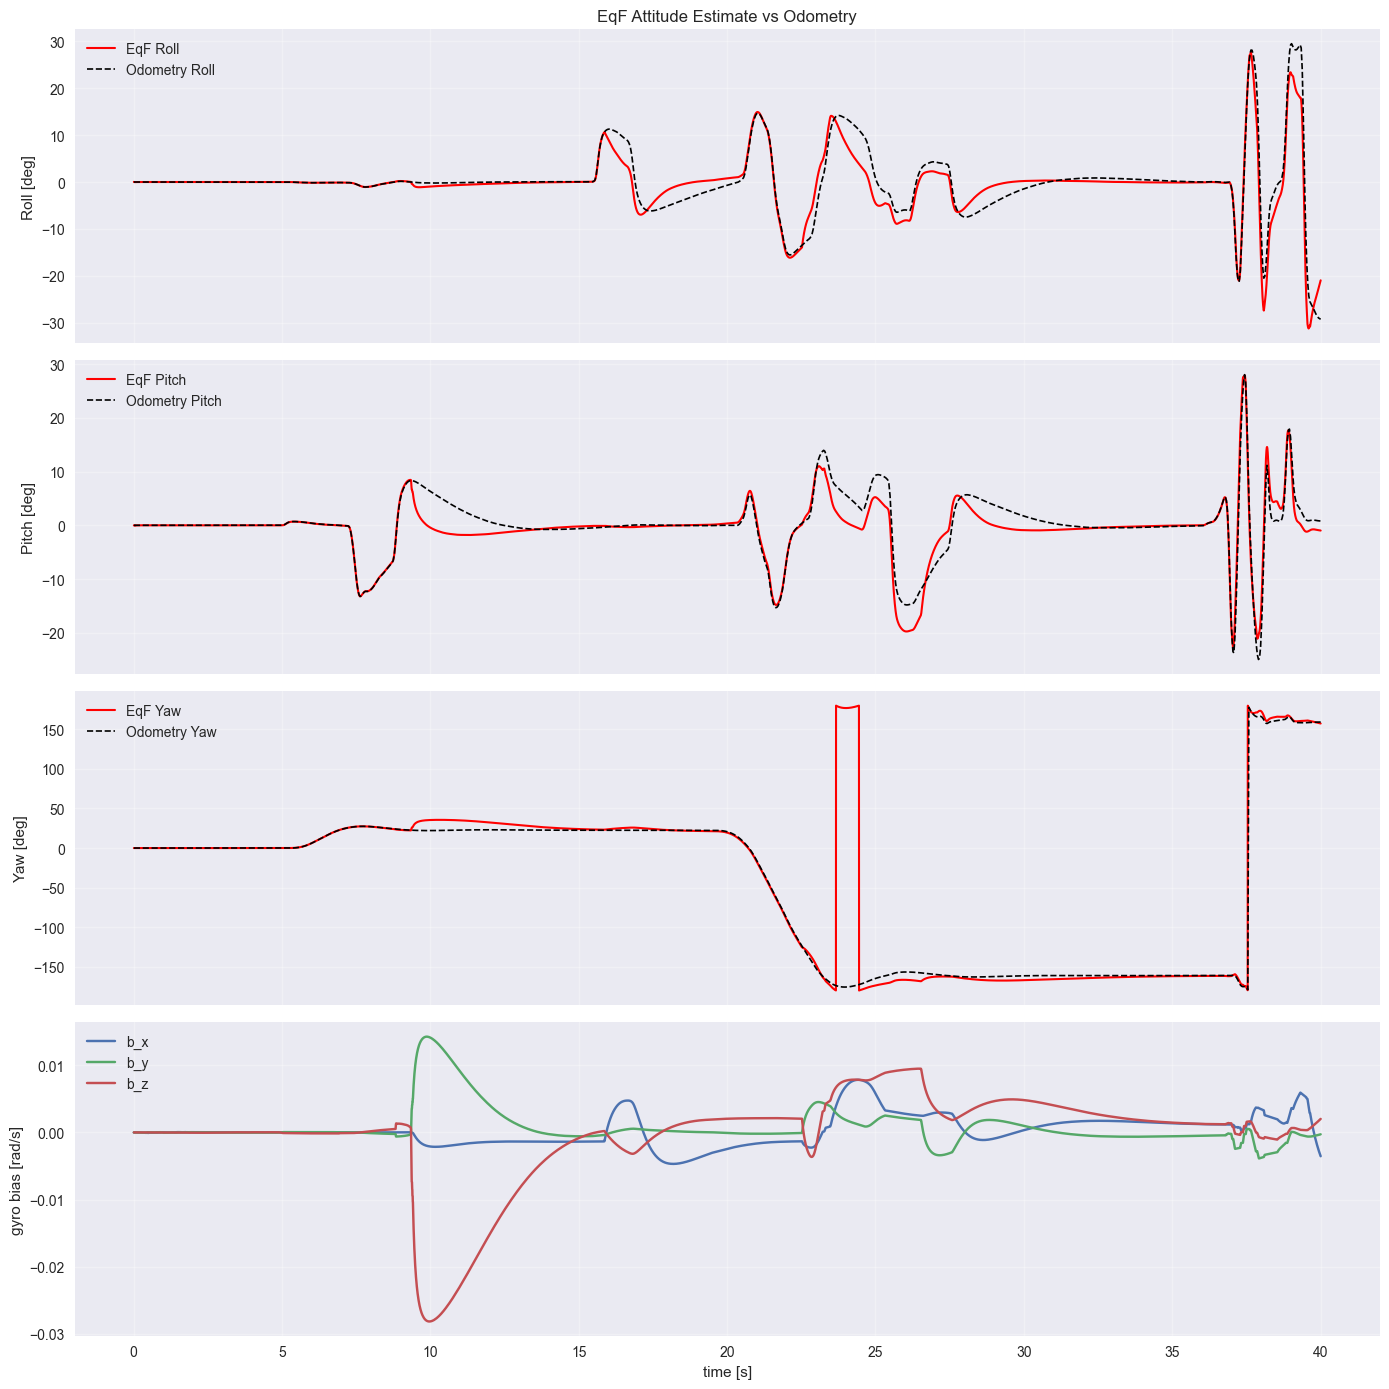

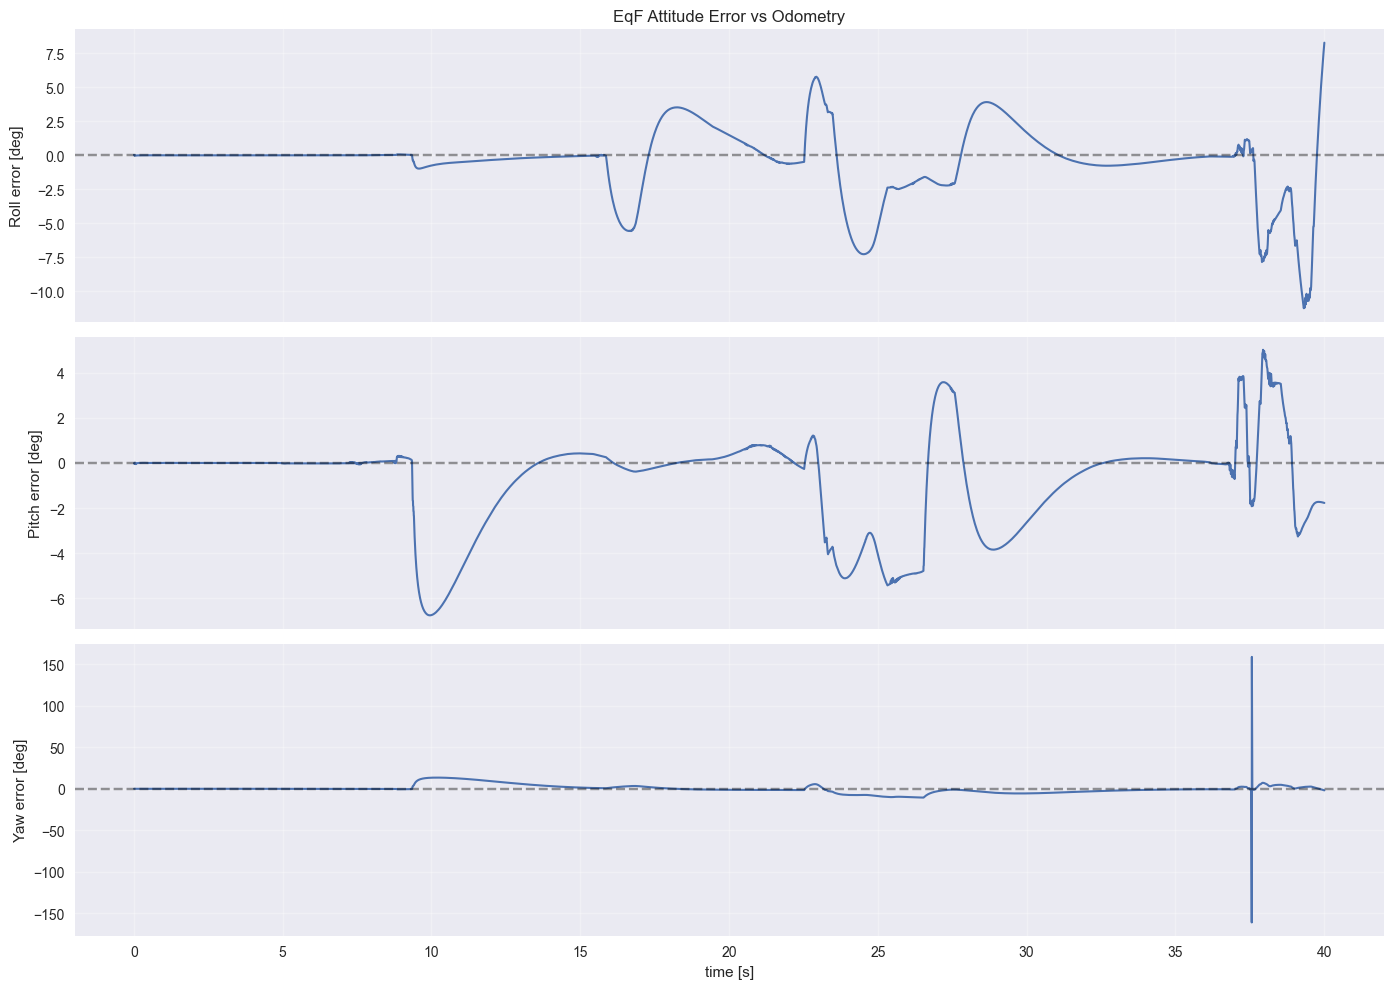

In [383]:
if 'eqf_time_array' in locals():
    true_euler_eqf = np.array([
        true_attitude_interp['roll'].iloc[:len(eqf_time_array)].values,
        true_attitude_interp['pitch'].iloc[:len(eqf_time_array)].values,
        true_attitude_interp['yaw'].iloc[:len(eqf_time_array)].values,
    ]).T

    def wrap_degrees(angle):
        return (angle + 180.0) % 360.0 - 180.0

    eqf_error = eqf_euler - true_euler_eqf
    eqf_error[:, 2] = wrap_degrees(eqf_error[:, 2])

    labels = ['Roll', 'Pitch', 'Yaw']
    print("=== EQF ATTITUDE ERROR STATISTICS ===")
    for i, label in enumerate(labels):
        mean_error = np.mean(eqf_error[:, i])
        std_error = np.std(eqf_error[:, i])
        rms_error = np.sqrt(np.mean(eqf_error[:, i] ** 2))
        print(f"  {label:5}: Mean = {mean_error:7.2f} deg, Std = {std_error:7.2f} deg, RMS = {rms_error:7.2f} deg")

    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
    for i, label in enumerate(labels):
        axes[i].plot(eqf_time_array, eqf_euler[:, i], 'r-', label=f'EqF {label}', linewidth=1.5)
        axes[i].plot(eqf_time_array, true_euler_eqf[:, i], 'k--', label=f'Odometry {label}', linewidth=1.2)
        axes[i].set_ylabel(f'{label} [deg]')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()

    axes[3].plot(eqf_time_array, eqf_bias[:, 0], label='b_x')
    axes[3].plot(eqf_time_array, eqf_bias[:, 1], label='b_y')
    axes[3].plot(eqf_time_array, eqf_bias[:, 2], label='b_z')
    axes[3].set_ylabel('gyro bias [rad/s]')
    axes[3].set_xlabel('time [s]')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()
    axes[0].set_title('EqF Attitude Estimate vs Odometry')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for i, label in enumerate(labels):
        axes[i].plot(eqf_time_array, eqf_error[:, i], linewidth=1.5)
        axes[i].axhline(0.0, color='k', linestyle='--', alpha=0.4)
        axes[i].set_ylabel(f'{label} error [deg]')
        axes[i].grid(True, alpha=0.3)
    axes[0].set_title('EqF Attitude Error vs Odometry')
    axes[-1].set_xlabel('time [s]')
    plt.tight_layout()
    plt.show()
else:
    print("No EqF results to plot. Run the EqF estimation cell first.")

In [384]:
if 'imu_filtered' in locals() and len(imu_filtered) > 0:
    initial_pos = np.array([0.0, 0.0, 0.0])      # Initial position
    initial_vel = np.array([0.0, 0.0, 0.0])      # Initial velocity  
    
    accel_state = np.array([0.0, 0.0, 1.0])

    initial_quat = np.array([
        true_attitude_interp['qw'].iloc[0],
        true_attitude_interp['qx'].iloc[0], 
        true_attitude_interp['qy'].iloc[0],
        true_attitude_interp['qz'].iloc[0]
    ])
    initial_quat = initial_quat / np.linalg.norm(initial_quat)
    
    X_current = create_se23_state(initial_pos, initial_vel, initial_quat)
    P_att = np.eye(3, dtype=float) * 0.1
    P_pos = np.eye(9, dtype=float) * 0.1
    
    # Storage for results
    timestamps = []
    attitudes_before = []  # Attitude from INS propagation only
    attitudes_after = []   # Attitude after mag/accel correction


    # run once to for the first timestep
    timestamp = imu_filtered.iloc[0]['timestamp']
    gyro = np.array([imu_filtered.iloc[0]['gyro_x'], 
                        imu_filtered.iloc[0]['gyro_y'], 
                        imu_filtered.iloc[0]['gyro_z']])
    accel = np.array([imu_filtered.iloc[0]['accel_x'], 
                        imu_filtered.iloc[0]['accel_y'], 
                        imu_filtered.iloc[0]['accel_z']])
    mag = np.array([mag_interp.iloc[0]['mag_x'], 
                    mag_interp.iloc[0]['mag_y'], 
                    mag_interp.iloc[0]['mag_z']])


    dt = 0.01
    attitudes_before.append(initial_quat.copy())

    result = estimator_type(
            initial_quat,
            mag,
            MAG_DECLINATION,
            gyro,
            accel,
            accel_state,
            ACCEL_GAIN,
            MAG_GAIN,
            dt,
            P_att
        )
    
    P_att = np.array(result[1]).reshape(3, 3)
    q_corrected = np.array(result[0]).flatten()
    q_corrected = q_corrected / np.linalg.norm(q_corrected)
    X_current[6:10] = q_corrected
    # Store results
    timestamps.append(timestamp)
    attitudes_after.append(q_corrected)

    
    for i in range(len(imu_filtered)):
        if (i == 0):
            continue
        # Get current data
        print(f"Processing timestep {i}")
        timestamp = imu_filtered.iloc[i]['timestamp']
        gyro = np.array([imu_filtered.iloc[i]['gyro_x'], 
                         imu_filtered.iloc[i]['gyro_y'], 
                         imu_filtered.iloc[i]['gyro_z']])
        accel = np.array([imu_filtered.iloc[i]['accel_x'], 
                          imu_filtered.iloc[i]['accel_y'], 
                          imu_filtered.iloc[i]['accel_z']])
        mag = np.array([mag_interp.iloc[i]['mag_x'], 
                        mag_interp.iloc[i]['mag_y'], 
                        mag_interp.iloc[i]['mag_z']])

        dt = timestamp - timestamps[-1]

        X_propagated = ins_propagate(X_current, accel, gyro, g, dt)
        X_propagated = np.array(X_propagated).flatten()
        
        q_before = extract_quaternion_from_se23(X_propagated)
        attitudes_before.append(q_before.copy())

        pos = extract_position_from_odom_interp(true_position_interp, i)
        result = position_correction(X_propagated, pos, accel, accel_state, dt, P_pos)

        X_propagated = np.array(result[0]).flatten()
        P_pos = np.array(result[1]).reshape(9, 9)
        accel_state = np.array(result[2]).flatten()
        
        result = estimator_type(
            q_before,
            mag,
            MAG_DECLINATION,
            gyro,
            accel,
            accel_state,
            ACCEL_GAIN,
            MAG_GAIN,
            dt,
            P_att
        )
            
        q_corrected = np.array(result[0]).flatten()
        q_corrected = q_corrected / np.linalg.norm(q_corrected)        
        
        P_att = np.array(result[1]).reshape(3, 3)
        #accel_w = np.array(result[2]).flatten()
        #accel_state = np.array(result[3]).flatten()

        #print(f"accel_w: {accel_w}")
        #print(f"accel_gps: {accel_state}")
        X_current = X_propagated.copy()
        X_current[6:10] = q_corrected
        
        # Store results
        timestamps.append(timestamp)
        attitudes_after.append(q_corrected)
        
        if i % 10 == 0:
            print(f"Processed {i+1}/{len(imu_filtered)} samples")
            if i == 0:
                print(f"  First timestep: using exact initial quaternion for both before/after")
    
    print("INS propagation and attitude estimation complete!")
    
    # Convert quaternions to Euler angles
    euler_before = np.array([quat_to_euler(q) for q in attitudes_before])
    euler_after = np.array([quat_to_euler(q) for q in attitudes_after])
    
    # Create time array for plotting
    time_array = np.array(timestamps)

    # Preserve the previous estimator output for side-by-side comparison with EqF.
    previous_filter_time_array = time_array.copy()
    previous_filter_euler_before = euler_before.copy()
    previous_filter_euler_after = euler_after.copy()
    previous_filter_quats = np.array(attitudes_after).copy()
    
else:
    print("No data to process!")


Processing timestep 1
Processing timestep 2
Processing timestep 3
Processing timestep 4
Processing timestep 5
Processing timestep 6
Processing timestep 7
Processing timestep 8
Processing timestep 9
Processing timestep 10
Processed 11/10000 samples
Processing timestep 11
Processing timestep 12
Processing timestep 13
Processing timestep 14
Processing timestep 15
Processing timestep 16
Processing timestep 17
Processing timestep 18
Processing timestep 19
Processing timestep 20
Processed 21/10000 samples
Processing timestep 21
Processing timestep 22
Processing timestep 23
Processing timestep 24
Processing timestep 25
Processing timestep 26
Processing timestep 27
Processing timestep 28
Processing timestep 29
Processing timestep 30
Processed 31/10000 samples
Processing timestep 31
Processing timestep 32
Processing timestep 33
Processing timestep 34
Processing timestep 35
Processing timestep 36
Processing timestep 37
Processing timestep 38
Processing timestep 39
Processing timestep 40
Processe

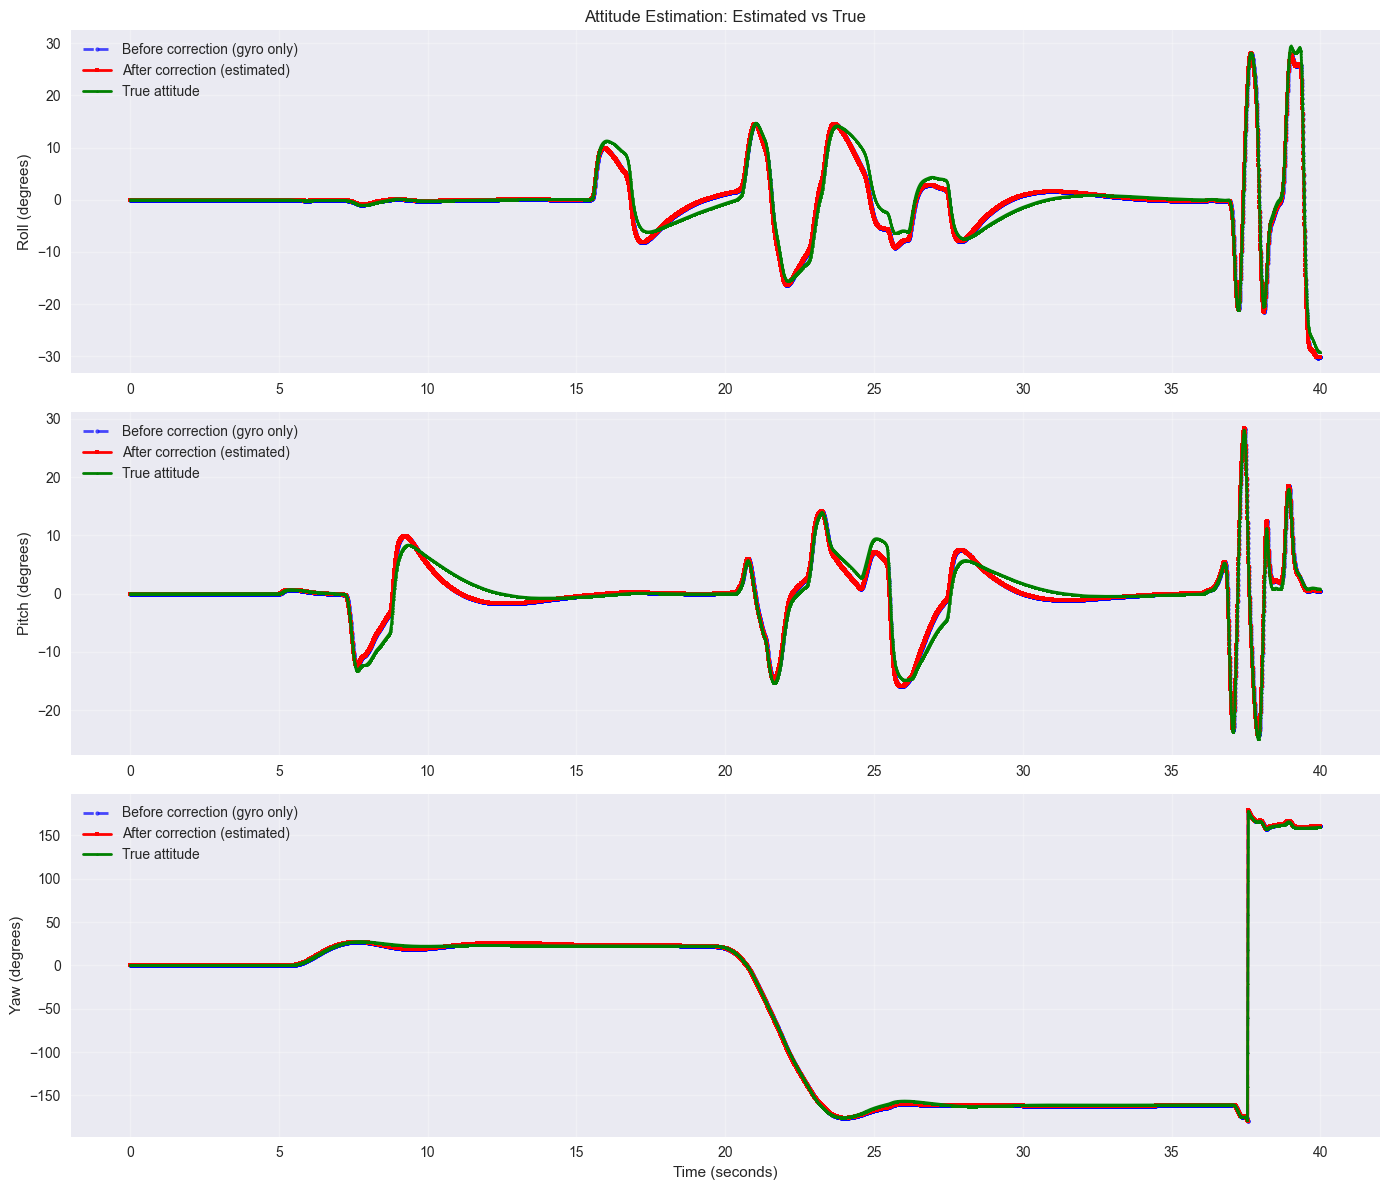

In [385]:
if 'time_array' in locals():
    # Plot attitude comparison
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Roll
    axes[0].plot(time_array, euler_before[:, 0], 'b--o', label='Before correction (gyro only)', 
                linewidth=2, markersize=3, alpha=0.7)
    axes[0].plot(time_array, euler_after[:, 0], 'r-s', label='After correction (estimated)', 
                linewidth=2, markersize=3)
    axes[0].plot(time_array, true_attitude_interp['roll'].iloc[:len(time_array)], 'g-^', 
                label='True attitude', linewidth=2, markersize=2)
    axes[0].set_ylabel('Roll (degrees)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Attitude Estimation: Estimated vs True')
    
    # Pitch
    axes[1].plot(time_array, euler_before[:, 1], 'b--o', label='Before correction (gyro only)', 
                linewidth=2, markersize=3, alpha=0.7)
    axes[1].plot(time_array, euler_after[:, 1], 'r-s', label='After correction (estimated)', 
                linewidth=2, markersize=3)
    axes[1].plot(time_array, true_attitude_interp['pitch'].iloc[:len(time_array)], 'g-^', 
                label='True attitude', linewidth=2, markersize=2)
    axes[1].set_ylabel('Pitch (degrees)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Yaw
    axes[2].plot(time_array, euler_before[:, 2], 'b--o', label='Before correction (gyro only)', 
                linewidth=2, markersize=3, alpha=0.7)
    axes[2].plot(time_array, euler_after[:, 2], 'r-s', label='After correction (estimated)', 
                linewidth=2, markersize=3)
    axes[2].plot(time_array, true_attitude_interp['yaw'].iloc[:len(time_array)], 'g-^', 
                label='True attitude', linewidth=2, markersize=2)
    axes[2].set_ylabel('Yaw (degrees)')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot!")


In [386]:
## Error Analysis: Estimated vs True Attitude


Removed 14 problematic points, keeping 9986 clean points
=== ATTITUDE ESTIMATION ERROR STATISTICS ===
\nAfter Correction (Clean Data):
  Roll : Mean =  -0.16°, Std =   1.38°, RMS =   1.39°
  Pitch: Mean =  -0.08°, Std =   1.23°, RMS =   1.24°
  Yaw  : Mean =  -0.09°, Std =   1.44°, RMS =   1.44°


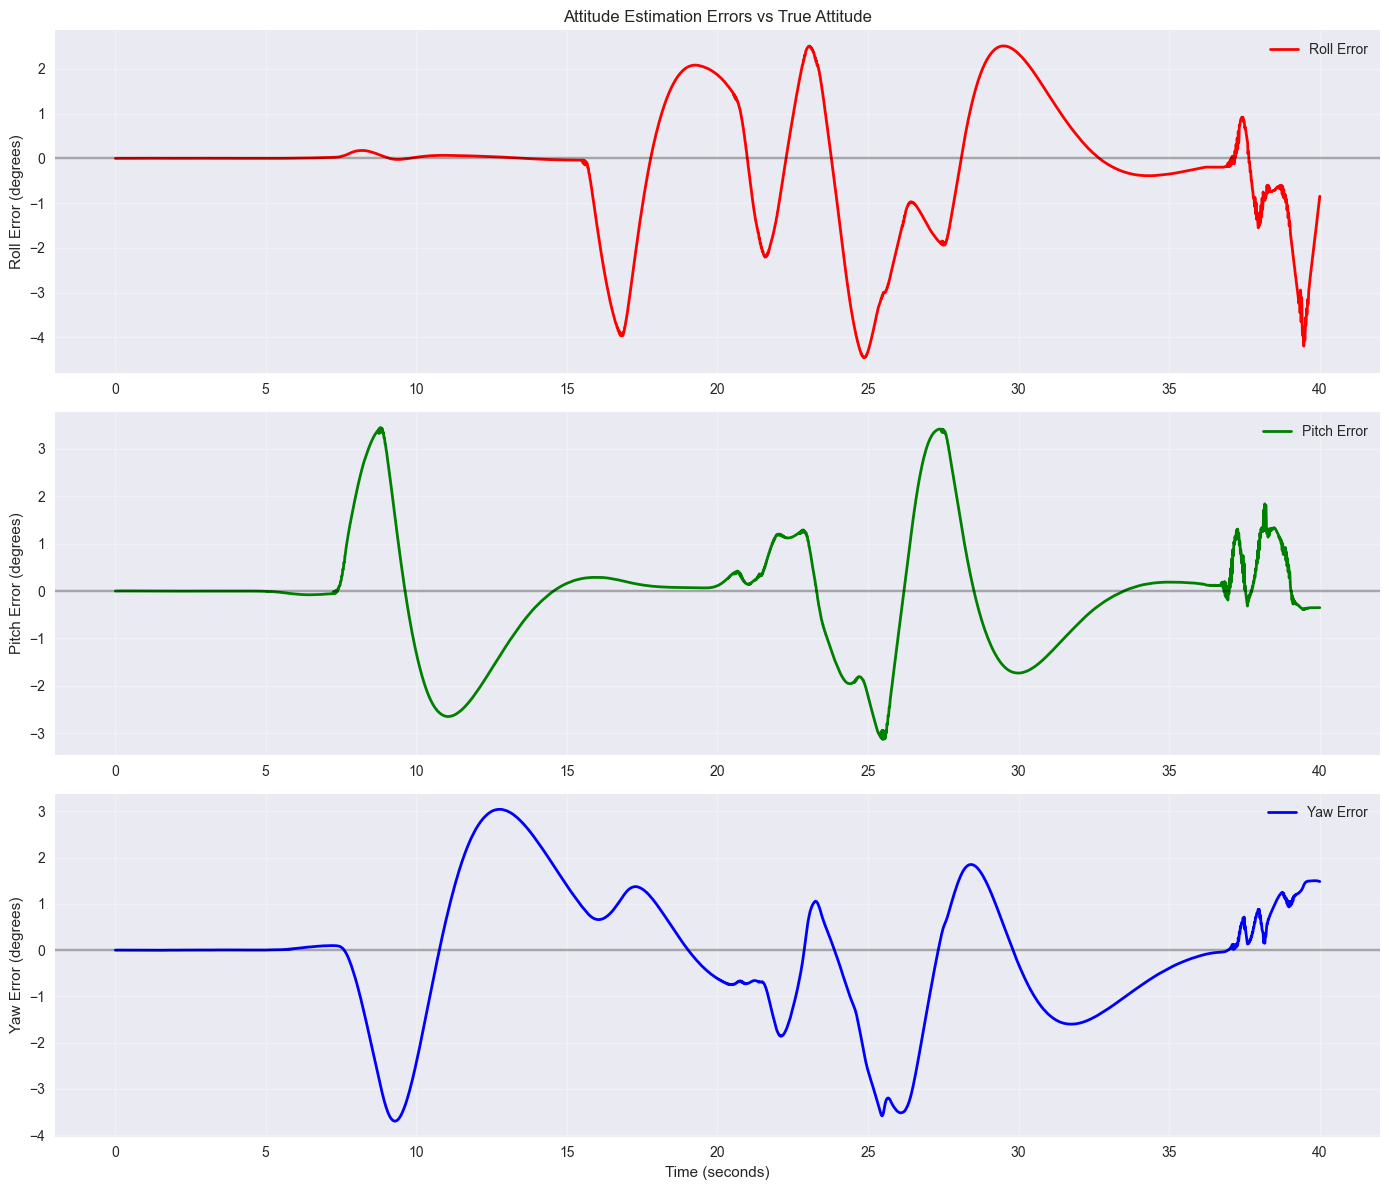

In [387]:
if 'time_array' in locals():
    # Calculate errors between estimated and true attitudes
    true_euler = np.array([
        true_attitude_interp['roll'].iloc[:len(time_array)].values,
        true_attitude_interp['pitch'].iloc[:len(time_array)].values, 
        true_attitude_interp['yaw'].iloc[:len(time_array)].values
    ]).T
    
    # Calculate errors (estimated - true)
    error_after = euler_after - true_euler
    
    # Handle angle wrapping for yaw errors (wrap to [-180, 180])
    def wrap_angle_degrees(angles):
        """Wrap angles to [-180, 180] degrees"""
        return np.mod(angles + 180, 360) - 180
    
    def detect_yaw_discontinuities(yaw_errors, threshold=150):
        """Detect points where yaw error jumps > threshold degrees between consecutive samples"""
        if len(yaw_errors) < 2:
            return np.ones(len(yaw_errors), dtype=bool)
        
        yaw_diff = np.abs(np.diff(yaw_errors))
        large_jumps = yaw_diff > threshold
        
        valid_mask = np.ones(len(yaw_errors), dtype=bool)
        jump_indices = np.where(large_jumps)[0]
        
        for idx in jump_indices:
            # Mark points around the jump as invalid
            start_idx = max(0, idx - 1)
            end_idx = min(len(valid_mask), idx + 3)
            valid_mask[start_idx:end_idx] = False
        
        return valid_mask
    
    def detect_unwrapping_issues(estimated_yaw, true_yaw, threshold=150):
        """Detect unwrapping issues by looking for sudden jumps in either signal"""
        est_jumps = np.abs(np.diff(estimated_yaw)) > threshold
        true_jumps = np.abs(np.diff(true_yaw)) > threshold
        
        valid_mask = np.ones(len(estimated_yaw), dtype=bool)
        all_jumps = np.where(np.logical_or(est_jumps, true_jumps))[0]
        
        for idx in all_jumps:
            start_idx = max(0, idx - 2)
            end_idx = min(len(valid_mask), idx + 4)
            valid_mask[start_idx:end_idx] = False
        
        return valid_mask
    
    # Wrap yaw errors
    error_after[:, 2] = wrap_angle_degrees(error_after[:, 2])
    
    # Create combined mask for all problematic points
    yaw_discontinuity_mask = detect_yaw_discontinuities(error_after[:, 2], threshold=150)
    yaw_unwrapping_mask = detect_unwrapping_issues(euler_after[:, 2], true_euler[:, 2], threshold=30)
    yaw_magnitude_mask = np.abs(error_after[:, 2]) < 170
    
    # Combined mask - keep only clean points
    valid_mask = np.logical_and.reduce([
        yaw_discontinuity_mask, 
        yaw_unwrapping_mask, 
        yaw_magnitude_mask,
    ])
    
    # Filter all data arrays to keep only valid points
    time_array = time_array[valid_mask]
    error_after = error_after[valid_mask]
    euler_after = euler_after[valid_mask]
    true_euler = true_euler[valid_mask]
    
    print(f"Removed {np.sum(~valid_mask)} problematic points, keeping {len(time_array)} clean points")
    
    # Calculate clean statistics
    labels = ['Roll', 'Pitch', 'Yaw']
    
    print("=== ATTITUDE ESTIMATION ERROR STATISTICS ===")
    print("\\nAfter Correction (Clean Data):")
    for i, label in enumerate(labels):
        mean_error = np.mean(error_after[:, i])
        std_error = np.std(error_after[:, i])
        rms_error = np.sqrt(np.mean(error_after[:, i]**2))
        print(f"  {label:5}: Mean = {mean_error:6.2f}°, Std = {std_error:6.2f}°, RMS = {rms_error:6.2f}°")

    # Plot clean results
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Roll error
    axes[0].plot(time_array, error_after[:, 0], 'r-', label='Roll Error', linewidth=2)
    axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[0].set_ylabel('Roll Error (degrees)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Attitude Estimation Errors vs True Attitude')
    
    # Pitch error
    axes[1].plot(time_array, error_after[:, 1], 'g-', label='Pitch Error', linewidth=2)
    axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[1].set_ylabel('Pitch Error (degrees)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Yaw error
    axes[2].plot(time_array, error_after[:, 2], 'b-', label='Yaw Error', linewidth=2)
    axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    axes[2].set_ylabel('Yaw Error (degrees)')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    #axes[2].set_ylim(-10, 10)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No results to analyze!")

## EqF vs Previous Filter Comparison

Run the data loading/preprocessing cells, then the EqF section, then the previous attitude-estimator section. This plot overlays both filters against odometry.

=== EQF VS PREVIOUS FILTER RMS ERROR ===
  Roll : EqF =    2.49 deg, Previous =    1.39 deg
  Pitch: EqF =    2.25 deg, Previous =    1.24 deg
  Yaw  : EqF =    5.58 deg, Previous =    3.42 deg


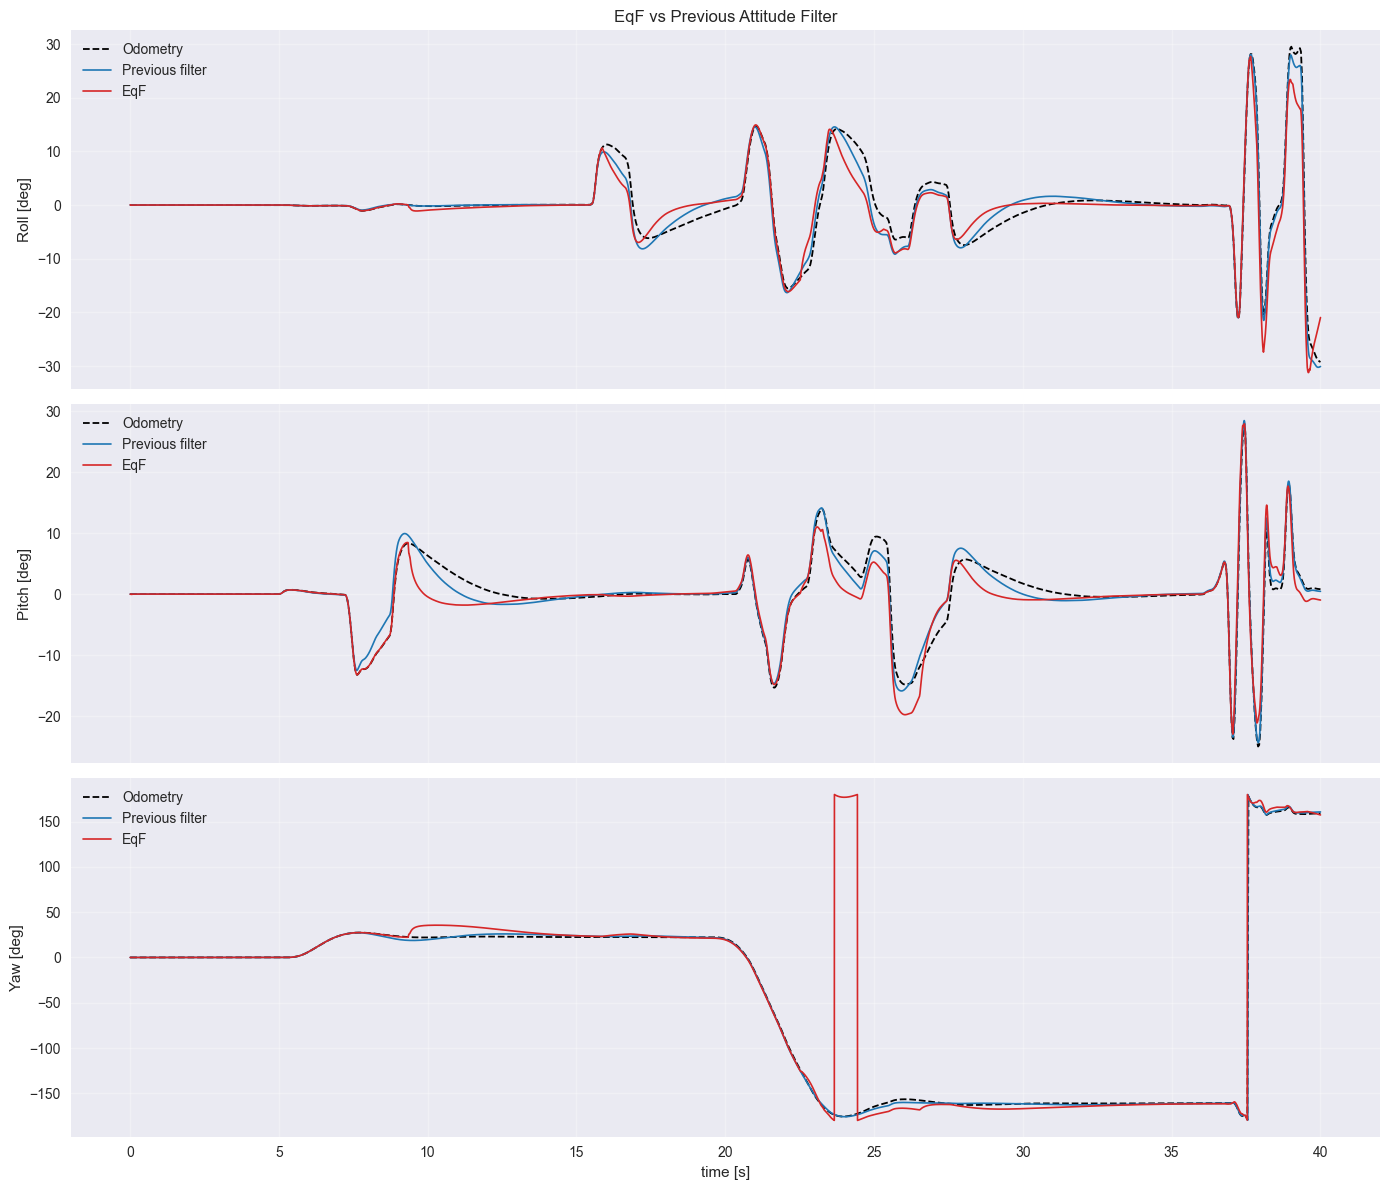

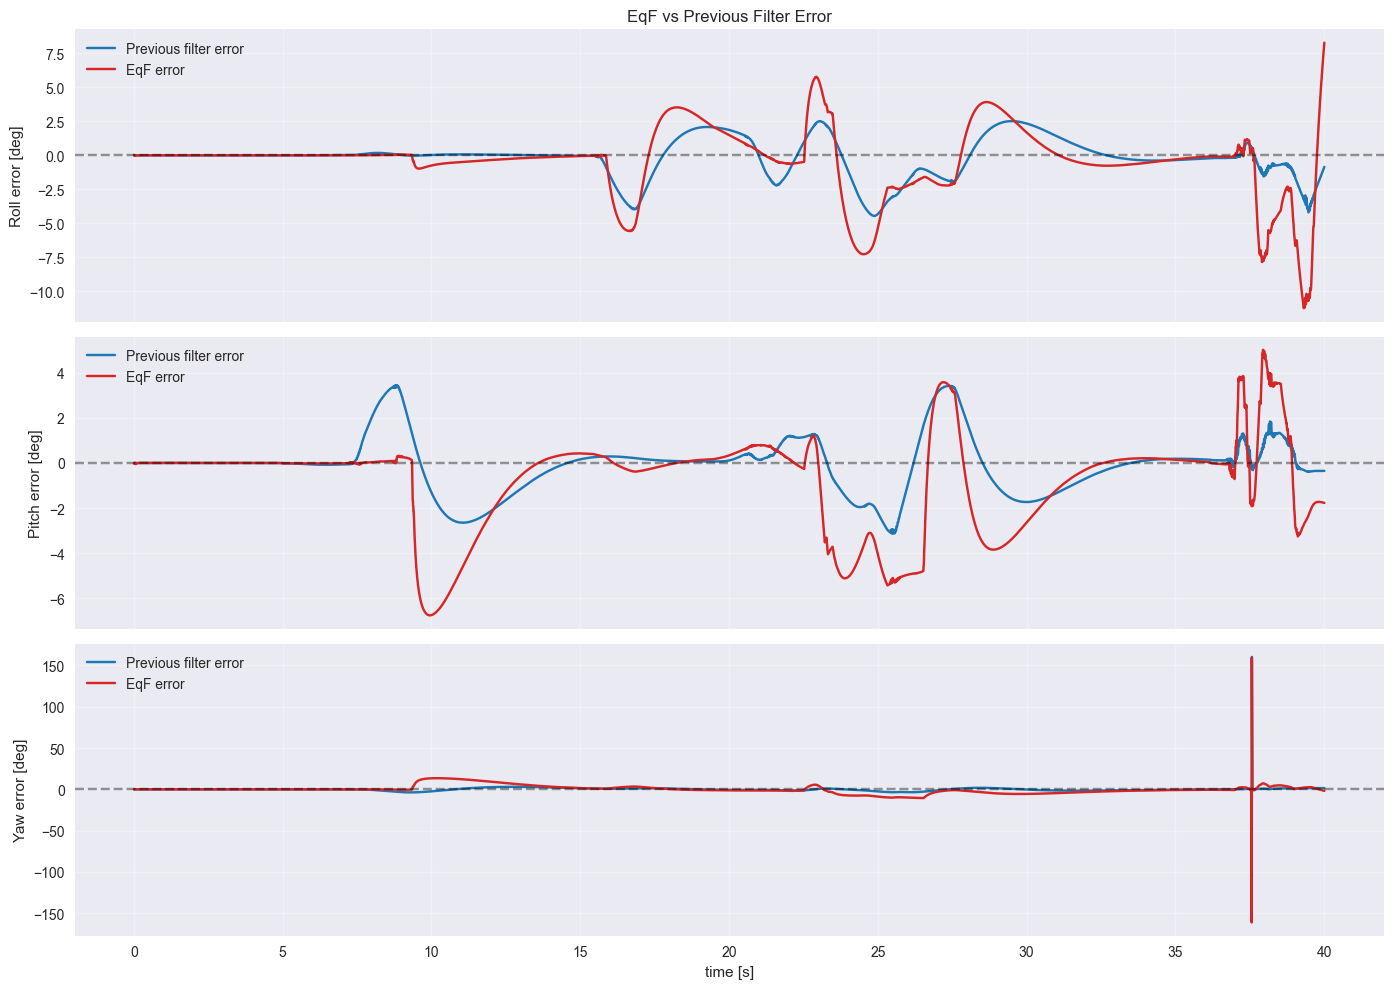

In [388]:
if 'eqf_time_array' in locals() and 'previous_filter_time_array' in locals():
    labels = ['Roll', 'Pitch', 'Yaw']

    n = min(len(eqf_time_array), len(previous_filter_time_array), len(true_attitude_interp))
    compare_time = eqf_time_array[:n]
    eqf_compare = eqf_euler[:n]
    previous_compare = previous_filter_euler_after[:n]
    true_compare = np.array([
        true_attitude_interp['roll'].iloc[:n].values,
        true_attitude_interp['pitch'].iloc[:n].values,
        true_attitude_interp['yaw'].iloc[:n].values,
    ]).T

    def wrap_degrees_compare(angle):
        return (angle + 180.0) % 360.0 - 180.0

    eqf_compare_error = eqf_compare - true_compare
    previous_compare_error = previous_compare - true_compare
    eqf_compare_error[:, 2] = wrap_degrees_compare(eqf_compare_error[:, 2])
    previous_compare_error[:, 2] = wrap_degrees_compare(previous_compare_error[:, 2])

    print("=== EQF VS PREVIOUS FILTER RMS ERROR ===")
    for i, label in enumerate(labels):
        eqf_rms = np.sqrt(np.mean(eqf_compare_error[:, i] ** 2))
        previous_rms = np.sqrt(np.mean(previous_compare_error[:, i] ** 2))
        print(f"  {label:5}: EqF = {eqf_rms:7.2f} deg, Previous = {previous_rms:7.2f} deg")

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    for i, label in enumerate(labels):
        axes[i].plot(compare_time, true_compare[:, i], 'k--', label='Odometry', linewidth=1.3)
        axes[i].plot(compare_time, previous_compare[:, i], color='tab:blue', label='Previous filter', linewidth=1.2)
        axes[i].plot(compare_time, eqf_compare[:, i], color='tab:red', label='EqF', linewidth=1.2)
        axes[i].set_ylabel(f'{label} [deg]')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
    axes[0].set_title('EqF vs Previous Attitude Filter')
    axes[-1].set_xlabel('time [s]')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    for i, label in enumerate(labels):
        axes[i].plot(compare_time, previous_compare_error[:, i], color='tab:blue', label='Previous filter error')
        axes[i].plot(compare_time, eqf_compare_error[:, i], color='tab:red', label='EqF error')
        axes[i].axhline(0.0, color='k', linestyle='--', alpha=0.4)
        axes[i].set_ylabel(f'{label} error [deg]')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
    axes[0].set_title('EqF vs Previous Filter Error')
    axes[-1].set_xlabel('time [s]')
    plt.tight_layout()
    plt.show()
else:
    print("Run both the EqF section and the previous attitude-estimator section before this comparison.")

## EqF NIS and NEES Consistency Checks

EqF NEES is attitude-only because the true gyro bias is not known from odometry. This section only computes consistency metrics for the EqF filter.

=== EQF CONSISTENCY SUMMARY ===
EqF attitude NEES mean: 15.33  (expected about 3)
EqF NIS mean:           0.26  (expected about 6)
Minimum posterior covariance eigenvalue: 1.116e-05


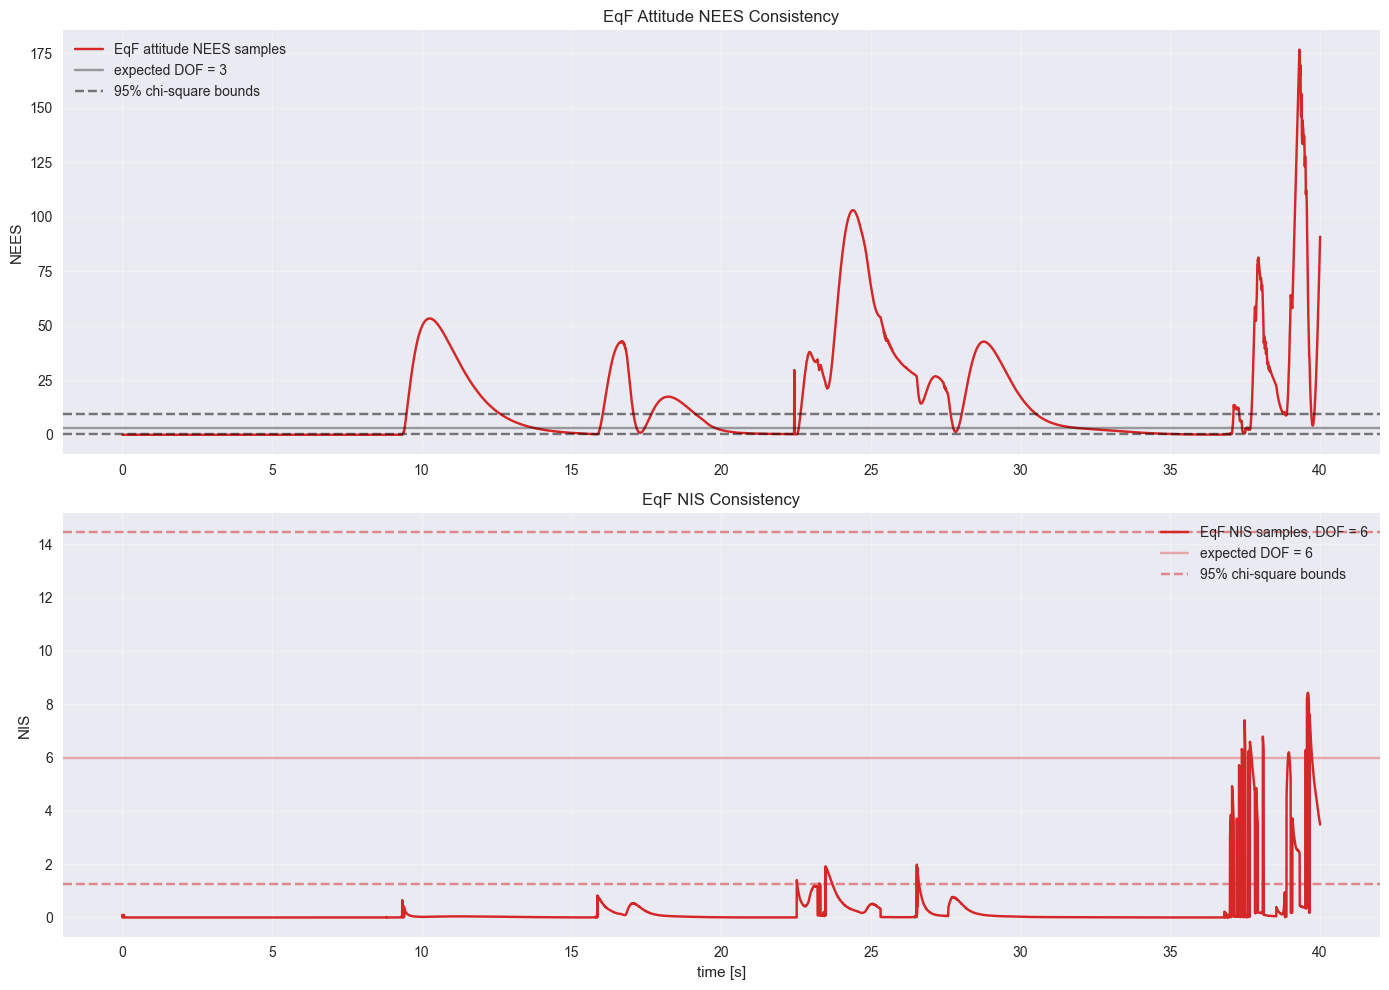

In [389]:
def chi_square_consistency_bounds(dof, confidence=0.95):
    alpha = 1.0 - confidence
    return chi2.ppf(alpha / 2.0, dof), chi2.ppf(1.0 - alpha / 2.0, dof)


if 'eqf_nis' in locals() and 'eqf_nees_att' in locals():
    nees_lower_95, nees_upper_95 = chi_square_consistency_bounds(3, confidence=0.95)
    nis_lower_95, nis_upper_95 = chi_square_consistency_bounds(6, confidence=0.95)

    consistency_window = min(500, len(eqf_time_array))
    eqf_nees_att_running = running_nanmean(eqf_nees_att, window=consistency_window)
    eqf_nis_running = running_nanmean(eqf_nis, window=consistency_window)
    running_time = eqf_time_array[consistency_window - 1:]

    print("=== EQF CONSISTENCY SUMMARY ===")
    print(f"EqF attitude NEES mean: {np.nanmean(eqf_nees_att):.2f}  (expected about 3)")
    print(f"EqF NIS mean:           {np.nanmean(eqf_nis):.2f}  (expected about 6)")
    if 'eqf_min_cov_eig' in locals():
        print(f"Minimum posterior covariance eigenvalue: {np.nanmin(eqf_min_cov_eig):.3e}")

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

    axes[0].plot(eqf_time_array, eqf_nees_att, color='tab:red', alpha=1.0, label='EqF attitude NEES samples')
    #axes[0].plot(running_time, eqf_nees_att_running, color='tab:red', linewidth=2.0, label=f'EqF NEES running mean ({consistency_window} samples)')
    axes[0].axhline(3.0, color='k', linestyle='-', alpha=0.35, label='expected DOF = 3')
    axes[0].axhline(nees_lower_95, color='k', linestyle='--', alpha=0.5, label='95% chi-square bounds')
    axes[0].axhline(nees_upper_95, color='k', linestyle='--', alpha=0.5)
    axes[0].set_ylabel('NEES')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[0].set_title('EqF Attitude NEES Consistency')

    axes[1].plot(eqf_time_array, eqf_nis, color='tab:red', alpha=1.0, label='EqF NIS samples, DOF = 6')
    #axes[1].plot(running_time, eqf_nis_running, color='tab:red', linewidth=2.0, label=f'EqF NIS running mean ({consistency_window} samples)')
    axes[1].axhline(6.0, color='tab:red', linestyle='-', alpha=0.35, label='expected DOF = 6')
    axes[1].axhline(nis_lower_95, color='tab:red', linestyle='--', alpha=0.5, label='95% chi-square bounds')
    axes[1].axhline(nis_upper_95, color='tab:red', linestyle='--', alpha=0.5)
    axes[1].set_ylabel('NIS')
    axes[1].set_xlabel('time [s]')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    axes[1].set_title('EqF NIS Consistency')

    plt.tight_layout()
    plt.show()
else:
    print("Run the EqF section before computing NIS/NEES.")

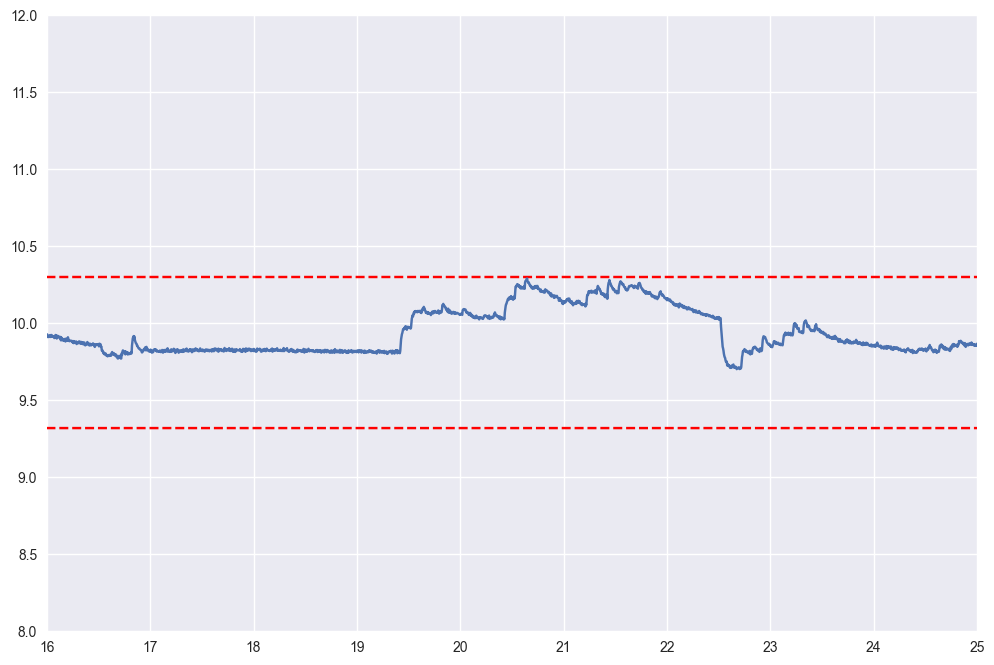

In [390]:
threshold = 0.05
accel_norm = np.sqrt(imu_data['accel_x']**2 + imu_data['accel_y']**2 + imu_data['accel_z']**2)
g_high = 9.81 * (1.0 + threshold)
g_low = 9.81 * (1.0 - threshold)
plt.plot(imu_data['timestamp'], g_high * np.ones(len(imu_data['timestamp'])), 'r--')
plt.plot(imu_data['timestamp'], g_low * np.ones(len(imu_data['timestamp'])), 'r--')
plt.plot(imu_data['timestamp'], accel_norm)
plt.xlim(16, 25)
plt.ylim(8, 12)
plt.show()
